# 딥러닝 입문 — 프로젝트 노트북

## 팀 정보

- **반 / 팀 번호**: A반 / 2팀
- **팀원 및 역할**:
  - 김민우: Baseline 정리, AUG(Data Augmentation), TL-FE(Transfer Learning Feature Extraction) 담당, 실험통합 및 결론, 최종점검 및 최종정리
  - 김민엽: RES(Residual CNN), TL-FT(Transfer Learning Fine-Tuning) 담당, 실험최종결론 정리
- **담당 실험 주제**: AUG / RES / TL-FE / TL-FT
- **베이스라인 최종 성능**: Baseline 실행 후 아래 실험 섹션에서 기록
  - **주요 실험 성능 요약**: 아래 값은 동일 조건 3회 실행 평균 기준으로 정리하였다.
  - Baseline CNN
    - 평균 Test Acc: 79.75% ± 1.21
    - 평균 최고 Val Acc: 86.44% ± 0.16
  - Baseline + Data Augmentation
    - 평균 Test Acc: 86.99% ± 0.59
    - 평균 최고 Val Acc: 89.52% ± 0.49
  - TL-FE
    - 평균 Test Acc: 88.55% ± 0.33
    - 평균 최고 Val Acc: 90.57% ± 0.24
  - Residual CNN
    - 평균 Test Acc: 89.68% ± 0.85
    - 평균 최고 Val Acc: 92.59% ± 0.63
  - TL-FT
    - 평균 Test Acc: 88.63% ± 0.06
    - 평균 최고 Val Acc: 92.59% ± 0.15

- **단일 실행 최고 Val Acc 기준**: Residual CNN 93.80%, TL-FT 92.40%, TL-FE 90.53%, AUG 89.36%, Baseline 85.96%
---


### ⚠️ 시작 전 필수: GPU 켜기
`런타임 → 런타임 유형 변경 → 하드웨어 가속기: T4 GPU → 저장`  
GPU 없이 돌리면 1 epoch에 시간이 오래 걸립니다. 아래 셀에서 `cuda`가 찍히는지 꼭 확인하세요.


---
## 0. 환경 설정

In [ ]:
# 라이브러리 임포트
import os
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms, datasets

# 재현성 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# 디바이스 확인 (cuda 가 나와야 정상)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
else:
    print('⚠️ GPU가 아닙니다! 런타임 유형을 T4 GPU로 변경 후 처음부터 다시 실행하세요.')


Device: cuda
GPU   : Tesla T4


---
## 1. 데이터 다운로드 (PlantVillage)

PlantVillage Color 데이터셋 (38 클래스, 약 54,000장)을 **gdown**으로 받습니다.
Kaggle 계정이 필요 없습니다. 이 셀은 처음 한 번만 다운로드하고, 이후에는 캐시를 재사용합니다.

> 압축 해제 후 클래스 폴더 위치는 자동으로 찾습니다.
> 혹시 못 찾으면 폴더 트리가 출력되니, 안내대로 `IMAGE_ROOT` 한 줄만 직접 지정하세요.

In [ ]:
!pip install -q gdown
import gdown

# 수업에서 공통 배포된 축소 데이터셋 (클래스당 150장)
# 배포 링크는 공개하지 않는다. 원본은 PlantVillage 공개 데이터셋에서 받을 수 있다.
GDRIVE_FILE_ID = '<<DATASET_FILE_ID>>'

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)
ZIP_PATH = DATA_DIR / 'plantvillage.zip'

# 클래스 폴더 탐지 헬퍼 (확장자 대소문자 무관)
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

def has_images(folder):
    try:
        for f in os.listdir(folder):
            if f.lower().endswith(IMG_EXTS):
                return True
    except (NotADirectoryError, PermissionError):
        pass
    return False

def find_image_root(start):
    # 하위에 '이미지를 직접 담은 폴더'가 10개 이상인 디렉토리를 클래스 루트로 판단
    for root, dirs, files in os.walk(start):
        subdirs = [d for d in dirs if not d.startswith('.')]
        class_like = [d for d in subdirs if has_images(os.path.join(root, d))]
        if len(class_like) >= 10:
            return Path(root)
    return None

def print_tree(start, max_depth=3):
    start = Path(start)
    base = len(start.parts)
    for root, dirs, files in os.walk(start):
        depth = len(Path(root).parts) - base
        if depth > max_depth:
            dirs[:] = []
            continue
        n_img = sum(1 for f in files if f.lower().endswith(IMG_EXTS))
        tag = f'  [이미지 {n_img}개]' if n_img else ''
        print('  ' * depth + f'{Path(root).name}/  (하위폴더 {len(dirs)}개){tag}')

# 데이터가 이미 있으면 다운로드/압축해제 스킵 (압축 위치 무관 자동 판단)
IMAGE_ROOT = find_image_root(DATA_DIR)

if IMAGE_ROOT is None:
    if not ZIP_PATH.exists():
        url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
        gdown.download(url, str(ZIP_PATH), quiet=False)
    print('압축 해제 중...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(DATA_DIR)
    print('완료')
    IMAGE_ROOT = find_image_root(DATA_DIR)
else:
    print('데이터가 이미 있습니다. 다운로드/압축해제 스킵')

if IMAGE_ROOT is None:
    print('❌ 클래스 폴더를 자동으로 못 찾았습니다. 압축 해제 구조:')
    print('-' * 60)
    print_tree(DATA_DIR, max_depth=3)
    print('-' * 60)
    print("위 트리에서 클래스 폴더(예: Apple___Black_rot)들이 직접 들어있는")
    print("디렉토리를 찾아 아래처럼 지정 후 이 셀을 다시 실행하세요. 예:")
    print("  IMAGE_ROOT = Path('./data/color')")
    raise SystemExit('IMAGE_ROOT 수동 지정 필요')

print(f'이미지 루트 경로: {IMAGE_ROOT}')
print(f'클래스 수       : {len(list(IMAGE_ROOT.iterdir()))}')


Downloading...
From (original): https://drive.google.com/uc?id=<<DATASET_FILE_ID>>
From (redirected): https://drive.google.com/uc?id=<<DATASET_FILE_ID>>&confirm=t&uuid=26dc6d3f-ca5f-4d7a-9d18-4383eb0f847f
To: /content/data/plantvillage.zip
100%|██████████| 858M/858M [00:08<00:00, 103MB/s] 


압축 해제 중...
완료
이미지 루트 경로: data/color
클래스 수       : 38


---
## 2. Dataset / DataLoader

### transform 분리 원칙 (중요)
- **train transform**: 학습용. **Augmentation 실험 팀은 여기를 수정**합니다.
- **eval transform**: val/test 공통. **절대 augmentation을 넣지 마세요** (평가가 오염됨).

> **왜 `TransformedSubset`을 쓰나요?**
> `random_split`은 원본 데이터셋 하나를 공유합니다. 그래서 `val_set.dataset.transform = ...`
> 처럼 바꾸면 **train_set의 transform까지 같이 바뀌는 버그**가 생깁니다.
> `TransformedSubset`은 분할은 그대로 두고 transform만 따로 입혀 이 문제를 막습니다.
> AUG 팀이 train transform을 바꿔도 val/test는 안전합니다.

# **2. Dataset / DataLoader(베이스라인용)**

In [ ]:

# PlantVillage(color) 통계값. Transfer Learning 팀은 ImageNet 통계로 바꾸세요:
#   IMAGENET_MEAN=[0.485,0.456,0.406], IMAGENET_STD=[0.229,0.224,0.225]
PLANT_MEAN = (0.4717, 0.4963, 0.3978)
PLANT_STD  = (0.1951, 0.1668, 0.1948)
IMG_SIZE = 128

# 평가용 transform (val/test 공통) - augmentation 절대 금지
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(PLANT_MEAN, PLANT_STD),
])

# 학습용 transform (베이스라인은 augmentation 없음)
# ───────────────────────────────────────────────────────────
# [AUG 실험 팀] 아래 Compose 안에 augmentation을 추가하세요.
# ⚠️ 데이터가 클래스당 150장으로 작습니다. 강한 변형(회전 큰 각도,
#    ColorJitter 3종 동시, 강한 색 변화)은 15 epoch 안에 수렴을 못 해
#    오히려 성능이 떨어집니다. '약하게' 시작해 조금씩 키우며 비교하세요.
# 약한 예시(권장 출발점):
#   transforms.RandomHorizontalFlip(p=0.5),
#   transforms.RandomRotation(10),
#   transforms.ColorJitter(brightness=0.1, contrast=0.1),
# 주의: 잎은 위/아래 구분이 있으므로 VerticalFlip은 신중히.
#       강도를 키울 거면 EPOCHS도 함께 늘려 공정 비교 조건을 맞추세요.
# ───────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # <-- AUG 팀: 이 줄들 사이에 augmentation 추가
    transforms.ToTensor(),
    transforms.Normalize(PLANT_MEAN, PLANT_STD),
])


In [ ]:
# transform을 안전하게 분리해주는 래퍼
# 중첩 구조(random_split -> Subset(클래스축소) -> ImageFolder)를 끝까지 풀어
# 원본 이미지를 직접 읽고 split마다 다른 transform을 안전하게 적용한다.
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def _resolve(self, idx):
        dataset = self.subset
        while isinstance(dataset, torch.utils.data.Subset):
            idx = dataset.indices[idx]
            dataset = dataset.dataset
        return dataset, idx

    def __getitem__(self, idx):
        image_folder, abs_idx = self._resolve(idx)
        path, label = image_folder.samples[abs_idx]
        img = image_folder.loader(path)        # 원본 PIL 이미지
        if self.transform is not None:
            img = self.transform(img)
        return img, label


# 원본 데이터셋
full_dataset = datasets.ImageFolder(str(IMAGE_ROOT), transform=None)
CLASSES = full_dataset.classes
NUM_CLASSES = len(CLASSES)

# ── 클래스당 이미지 수 제한 (난이도 조절) ───────────────────────
# PlantVillage 전체를 쓰면 baseline조차 95%+가 나와 실험 간 차이가 안 보입니다.
# 클래스당 일부만 사용해 변별력을 확보합니다.
# ⚠️ PER_CLASS와 SEED는 모든 팀이 동일하게 두세요 (공정 비교의 전제).
PER_CLASS = 150

import random as _rnd
from collections import defaultdict
from torch.utils.data import Subset
_rnd.seed(SEED)

_by_class = defaultdict(list)
for idx, label in enumerate(full_dataset.targets):
    _by_class[label].append(idx)
selected = []
for label, idxs in _by_class.items():
    _rnd.shuffle(idxs)
    selected.extend(idxs[:PER_CLASS])
_rnd.shuffle(selected)
base_dataset = Subset(full_dataset, selected)

print(f'Num classes : {NUM_CLASSES}')
print(f'클래스당 제한: {PER_CLASS}장')
print(f'사용 이미지  : {len(base_dataset):,}  (원본 {len(full_dataset):,})')

# 70 / 15 / 15 분할 (강사 참고본과 동일 비율·시드)
N = len(base_dataset)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)
n_test  = N - n_train - n_val
g = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(base_dataset, [n_train, n_val, n_test], generator=g)

train_ds       = TransformedSubset(train_set, train_transform)
train_eval_ds  = TransformedSubset(train_set, eval_transform)   # train acc 측정용(증강 X)
val_ds         = TransformedSubset(val_set,   eval_transform)
test_ds        = TransformedSubset(test_set,  eval_transform)

# GPU 없으면 pin_memory 경고가 나므로 자동 분기
PIN = torch.cuda.is_available()
BATCH_SIZE = 64

train_loader      = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=PIN)
train_eval_loader = DataLoader(train_eval_ds, batch_size=128, shuffle=False,
                               num_workers=2, pin_memory=PIN)
val_loader        = DataLoader(val_ds,   batch_size=128, shuffle=False,
                               num_workers=2, pin_memory=PIN)
test_loader       = DataLoader(test_ds,  batch_size=128, shuffle=False,
                               num_workers=2, pin_memory=PIN)

print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')


Num classes : 38
클래스당 제한: 150장
사용 이미지  : 5,700  (원본 54,305)
Train: 3,989 | Val: 855 | Test: 856


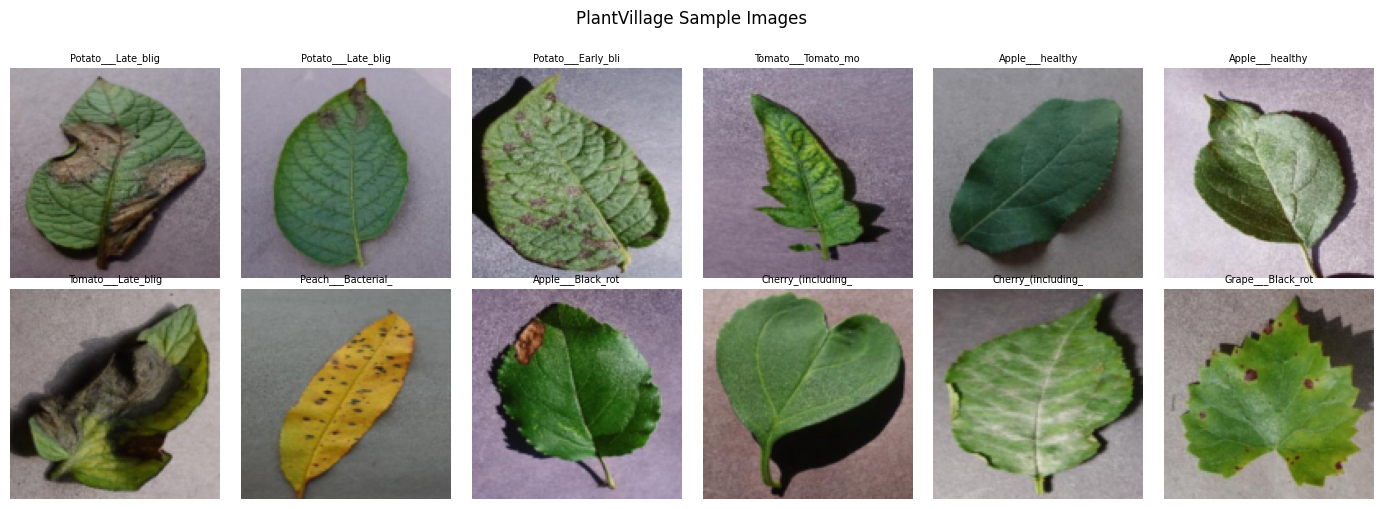

In [ ]:
# 샘플 이미지 시각화 (normalize 되돌려서 표시)
inv_mean = torch.tensor(PLANT_MEAN).view(3, 1, 1)
inv_std  = torch.tensor(PLANT_STD).view(3, 1, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    img = images[i] * inv_std + inv_mean
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
    ax.set_title(CLASSES[labels[i]][:18], fontsize=7)
    ax.axis('off')
plt.suptitle('PlantVillage Sample Images', y=1.01)
plt.tight_layout(); plt.show()


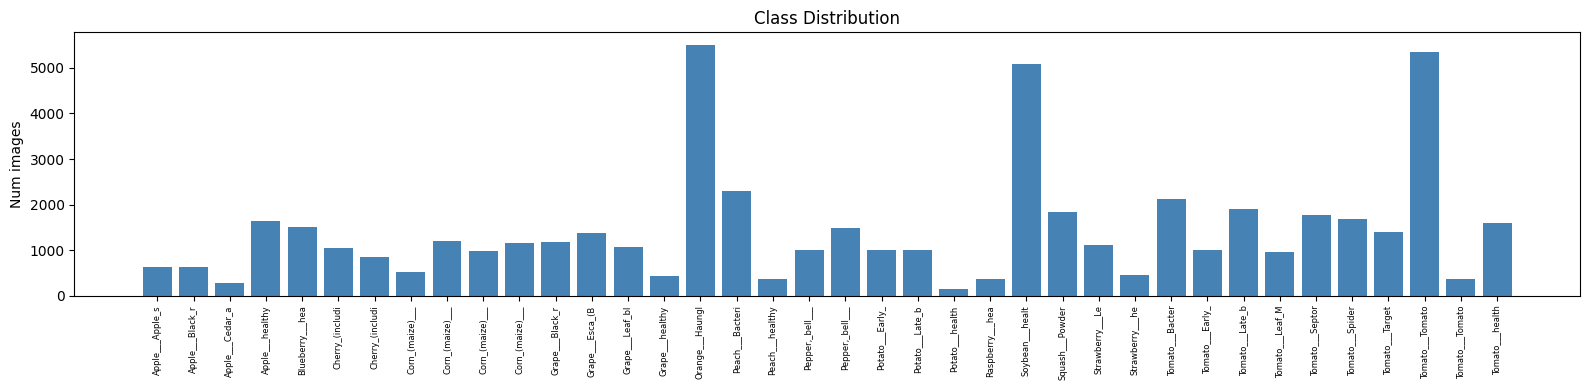

Min: 152 | Max: 5507 | Mean: 1429


In [ ]:
# 클래스 분포 확인 (불균형 정도 파악 - OPT/ARCH 팀 참고)
label_counts = Counter([label for _, label in full_dataset.samples])
counts = [label_counts[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(16, 4))
plt.bar(range(NUM_CLASSES), counts, color='steelblue')
plt.xticks(range(NUM_CLASSES), [c[:15] for c in CLASSES], rotation=90, fontsize=6)
plt.ylabel('Num images'); plt.title('Class Distribution')
plt.tight_layout(); plt.show()
print(f'Min: {min(counts)} | Max: {max(counts)} | Mean: {np.mean(counts):.0f}')


# **2. Dataset / DataLoader(AUG용)**

In [ ]:
# ============================================================
# 2. Dataset / DataLoader
# Baseline용 loader와 AUG 실험용 loader를 함께 구성한다.
# ============================================================

# PlantVillage(color) 통계값
# Transfer Learning 팀은 ImageNet 통계로 별도 transform을 만들어 사용하세요:
#   IMAGENET_MEAN = [0.485, 0.456, 0.406]
#   IMAGENET_STD  = [0.229, 0.224, 0.225]
PLANT_MEAN = (0.4717, 0.4963, 0.3978)
PLANT_STD  = (0.1951, 0.1668, 0.1948)
IMG_SIZE = 128

# ------------------------------------------------------------
# 평가용 transform: val/test 공통
# ------------------------------------------------------------
# validation/test 데이터에는 augmentation을 절대 적용하지 않는다.
# 평가 데이터까지 변형하면 모델 성능 비교가 불공정해지기 때문이다.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(PLANT_MEAN, PLANT_STD),
])

# ------------------------------------------------------------
# Baseline 학습용 transform
# ------------------------------------------------------------
# Baseline은 augmentation 없이 Resize + Normalize만 적용한다.
# 이 transform으로 기준 성능을 먼저 측정한다.
baseline_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(PLANT_MEAN, PLANT_STD),
])

# ------------------------------------------------------------
# AUG 실험용 transform
# ------------------------------------------------------------
# [AUG 실험 팀]
# 교수님 기본서의 지시에 따라 train transform의 Compose 안에 augmentation을 추가한다.
#
# 데이터가 클래스당 150장으로 작기 때문에 강한 변형은 피하고,
# 권장 출발점 수준의 약한 augmentation만 적용한다.
#
# 적용한 augmentation:
# 1. RandomHorizontalFlip(p=0.5)
#    - 잎의 좌우 방향 변화에 덜 민감하게 학습하기 위함
# 2. RandomRotation(10)
#    - 촬영 각도 차이에 대응하기 위함
# 3. ColorJitter(brightness=0.1, contrast=0.1)
#    - 조명과 대비 변화에 대응하기 위함
#
# 주의:
# - VerticalFlip은 잎의 위/아래 구조를 바꿀 수 있어 사용하지 않는다.
# - validation/test에는 augmentation을 적용하지 않는다.
# - 강도를 더 키우려면 EPOCHS도 함께 조정해야 공정하다.
aug_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(PLANT_MEAN, PLANT_STD),
])

# 기존 starter notebook과의 호환성 유지
# 기존 baseline 학습 코드가 train_transform이라는 이름을 사용할 수 있으므로
# train_transform은 baseline 기준으로 둔다.
train_transform = baseline_train_transform


# ============================================================
# transform을 안전하게 분리해주는 래퍼
# ============================================================
# random_split으로 만들어진 Subset 구조에서도
# 원본 이미지를 직접 읽고 split마다 다른 transform을 적용할 수 있게 한다.
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def _resolve(self, idx):
        dataset = self.subset

        # random_split, Subset 등으로 중첩된 구조를 끝까지 풀어 원본 ImageFolder에 접근
        while isinstance(dataset, torch.utils.data.Subset):
            idx = dataset.indices[idx]
            dataset = dataset.dataset

        return dataset, idx

    def __getitem__(self, idx):
        image_folder, abs_idx = self._resolve(idx)
        path, label = image_folder.samples[abs_idx]
        img = image_folder.loader(path)       # 원본 PIL 이미지 로드

        if self.transform is not None:
            img = self.transform(img)

        return img, label


# ============================================================
# 원본 데이터셋 로드
# ============================================================
full_dataset = datasets.ImageFolder(str(IMAGE_ROOT), transform=None)
CLASSES = full_dataset.classes
NUM_CLASSES = len(CLASSES)

# ------------------------------------------------------------
# 클래스당 이미지 수 제한
# ------------------------------------------------------------
# PlantVillage 전체를 쓰면 baseline조차 너무 높은 성능이 나와
# 기법별 차이가 잘 보이지 않을 수 있다.
# 따라서 클래스당 150장만 사용하여 실험 간 변별력을 확보한다.
PER_CLASS = 150

import random as _rnd
from collections import defaultdict
from torch.utils.data import Subset

_rnd.seed(SEED)

_by_class = defaultdict(list)
for idx, label in enumerate(full_dataset.targets):
    _by_class[label].append(idx)

selected = []
for label, idxs in _by_class.items():
    _rnd.shuffle(idxs)
    selected.extend(idxs[:PER_CLASS])

_rnd.shuffle(selected)
base_dataset = Subset(full_dataset, selected)

print(f'Num classes : {NUM_CLASSES}')
print(f'클래스당 제한: {PER_CLASS}장')
print(f'사용 이미지  : {len(base_dataset):,}  (원본 {len(full_dataset):,})')


# ============================================================
# train / validation / test split
# ============================================================
# 모든 실험이 동일한 데이터를 사용해야 공정하므로
# split 비율과 seed는 동일하게 유지한다.
N = len(base_dataset)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)
n_test  = N - n_train - n_val

g = torch.Generator().manual_seed(SEED)
train_set, val_set, test_set = random_split(
    base_dataset,
    [n_train, n_val, n_test],
    generator=g
)


# ============================================================
# Baseline / AUG Dataset 분리
# ============================================================
# 같은 train_set을 사용하되 transform만 다르게 적용한다.
#
# baseline_train_ds:
# - augmentation 없음
# - Baseline SimpleCNN 학습에 사용
#
# aug_train_ds:
# - train 데이터에만 약한 augmentation 적용
# - AUG 실험 모델 학습에 사용
#
# train_eval_ds / val_ds / test_ds:
# - augmentation 없음
# - 모든 실험의 평가 기준을 동일하게 맞추기 위해 공통 사용
baseline_train_ds = TransformedSubset(train_set, baseline_train_transform)
aug_train_ds      = TransformedSubset(train_set, aug_train_transform)

train_eval_ds = TransformedSubset(train_set, eval_transform)   # train acc 측정용, 증강 X
val_ds        = TransformedSubset(val_set,   eval_transform)   # validation, 증강 X
test_ds       = TransformedSubset(test_set,  eval_transform)   # test, 증강 X

# 기존 baseline 코드 호환용
train_ds = baseline_train_ds


# ============================================================
# DataLoader 생성
# ============================================================
PIN = torch.cuda.is_available()
BATCH_SIZE = 64

# Baseline 학습용 loader
# 기존 baseline 학습 셀은 train_loader를 그대로 사용한다.
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=PIN
)

# AUG 학습용 loader
# AUG 실험 셀에서는 train_loader 대신 aug_train_loader를 사용한다.
aug_train_loader = DataLoader(
    aug_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=PIN
)

# 공통 평가용 loader
# 모든 실험에서 평가 기준을 동일하게 맞추기 위해 augmentation 없는 loader를 사용한다.
train_eval_loader = DataLoader(
    train_eval_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN
)

val_loader = DataLoader(
    val_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN
)

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN
)

print(f'Train baseline: {len(baseline_train_ds):,}')
print(f'Train AUG     : {len(aug_train_ds):,}')
print(f'Val           : {len(val_ds):,}')
print(f'Test          : {len(test_ds):,}')
print()
print('Baseline 학습용 loader : train_loader')
print('AUG 학습용 loader      : aug_train_loader')
print('공통 평가용 loader     : train_eval_loader, val_loader, test_loader')

Num classes : 38
클래스당 제한: 150장
사용 이미지  : 5,700  (원본 54,305)
Train baseline: 3,989
Train AUG     : 3,989
Val           : 855
Test          : 856

Baseline 학습용 loader : train_loader
AUG 학습용 loader      : aug_train_loader
공통 평가용 loader     : train_eval_loader, val_loader, test_loader


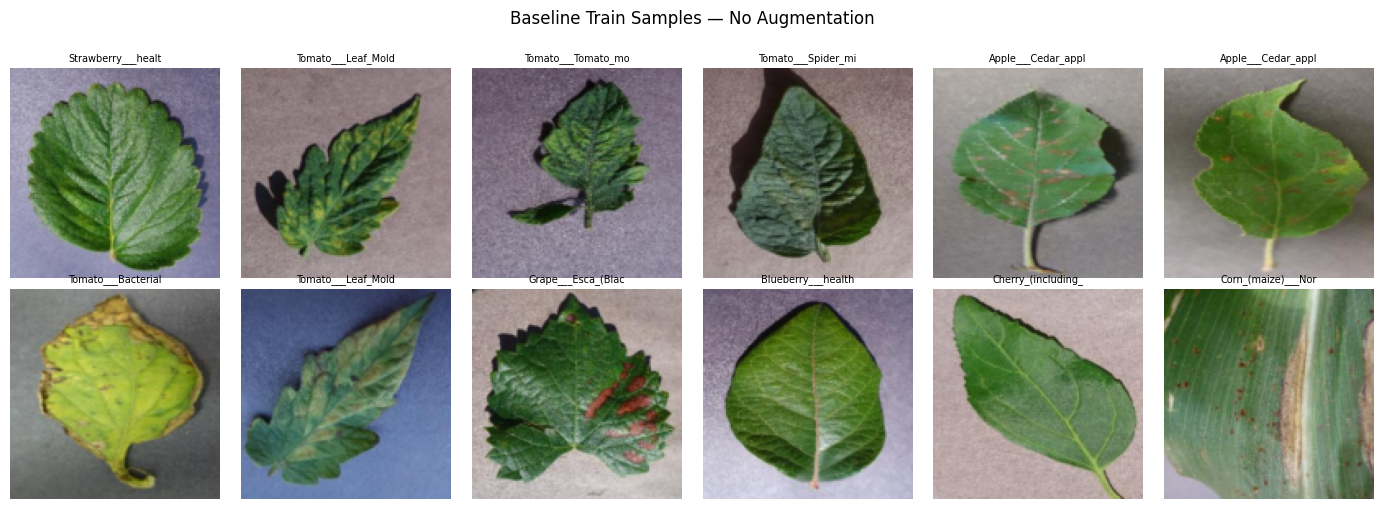

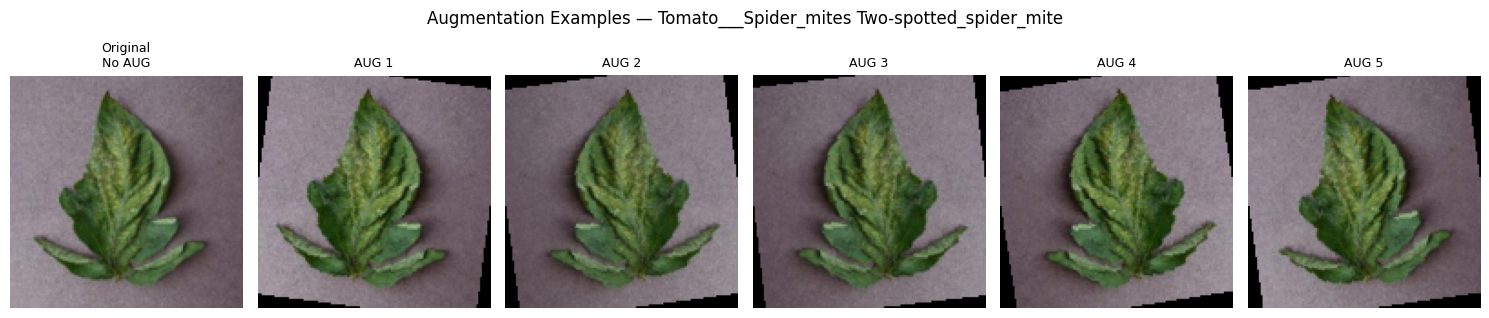

In [ ]:
# ============================================================
# 샘플 이미지 시각화
# ============================================================
# Baseline 입력 이미지와 AUG가 적용된 이미지를 함께 확인한다.
# 이 셀은 Dataset / DataLoader 파트에 속한다.
#
# 목적:
# - 입력 이미지가 정상적으로 로드되는지 확인
# - AUG가 실제로 어떤 변형을 만드는지 확인
# - 변형 강도가 과하지 않은지 눈으로 점검
# ============================================================

def denormalize_for_plot(img_tensor, mean=PLANT_MEAN, std=PLANT_STD):
    """
    Normalize된 tensor 이미지를 다시 사람이 볼 수 있는 RGB 이미지로 복원한다.
    """
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    return img


# ------------------------------------------------------------
# 1. Baseline 입력 이미지 시각화
# ------------------------------------------------------------
# augmentation이 없는 baseline train_loader에서 샘플을 확인한다.
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize_for_plot(images[i]))
    ax.set_title(CLASSES[labels[i]][:18], fontsize=7)
    ax.axis('off')

plt.suptitle('Baseline Train Samples — No Augmentation', y=1.01)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. AUG 적용 예시 시각화
# ------------------------------------------------------------
# 같은 원본 이미지에 augmentation을 여러 번 적용하여
# RandomHorizontalFlip, RandomRotation, ColorJitter가 어느 정도로 작동하는지 확인한다.
sample_idx = 0

baseline_vis_ds = TransformedSubset(train_set, baseline_train_transform)
aug_vis_ds      = TransformedSubset(train_set, aug_train_transform)

original_img, original_label = baseline_vis_ds[sample_idx]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))

axes[0].imshow(denormalize_for_plot(original_img))
axes[0].set_title('Original\nNo AUG', fontsize=9)
axes[0].axis('off')

# 같은 index를 여러 번 호출하면 Random transform 때문에 매번 조금씩 다르게 변형된다.
for i in range(1, 6):
    aug_img, _ = aug_vis_ds[sample_idx]
    axes[i].imshow(denormalize_for_plot(aug_img))
    axes[i].set_title(f'AUG {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle(f'Augmentation Examples — {CLASSES[original_label]}', y=1.05)
plt.tight_layout()
plt.show()

# **2. Dataset / DataLoader(TL-FE용)**

In [ ]:
# ============================================================
# TL-FE용 Transform / DataLoader 추가
# ============================================================
# TL-FE는 ImageNet으로 사전학습된 ResNet18을 사용한다.
# 따라서 PlantVillage 통계값이 아니라 ImageNet 통계값으로 Normalize한다.
#
# 주의:
# - 기존 train_loader, val_loader, test_loader는 Baseline/AUG용으로 그대로 둔다.
# - TL-FE용 loader는 tlfe_ 접두사를 붙여 따로 만든다.
# - train/val/test split은 기존과 동일하게 사용하여 공정 비교를 유지한다.
# ============================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# TL-FE 학습용 transform
# Feature Extraction 실험에서는 augmentation을 섞지 않는다.
# 이번 실험의 핵심은 "사전학습 ResNet18 + fc만 학습"이기 때문이다.
tlfe_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# TL-FE 평가용 transform
# val/test에는 augmentation을 절대 적용하지 않는다.
tlfe_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# 기존 train/val/test split은 그대로 사용하고 transform만 TL-FE용으로 바꾼다.
tlfe_train_ds      = TransformedSubset(train_set, tlfe_train_transform)
tlfe_train_eval_ds = TransformedSubset(train_set, tlfe_eval_transform)
tlfe_val_ds        = TransformedSubset(val_set,   tlfe_eval_transform)
tlfe_test_ds       = TransformedSubset(test_set,  tlfe_eval_transform)

# TL-FE 학습용 loader
tlfe_train_loader = DataLoader(
    tlfe_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=PIN
)

# TL-FE 평가용 loader
tlfe_train_eval_loader = DataLoader(
    tlfe_train_eval_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN
)

tlfe_val_loader = DataLoader(
    tlfe_val_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN
)

tlfe_test_loader = DataLoader(
    tlfe_test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=PIN
)

print('===== TL-FE DataLoader 생성 완료 =====')
print(f'TL-FE train      : {len(tlfe_train_ds):,}')
print(f'TL-FE validation : {len(tlfe_val_ds):,}')
print(f'TL-FE test       : {len(tlfe_test_ds):,}')
print()
print('Baseline/AUG loader와 TL-FE loader는 서로 분리되어 있습니다.')
print('Baseline/AUG : train_loader, aug_train_loader, val_loader, test_loader')
print('TL-FE        : tlfe_train_loader, tlfe_val_loader, tlfe_test_loader')

===== TL-FE DataLoader 생성 완료 =====
TL-FE train      : 3,989
TL-FE validation : 855
TL-FE test       : 856

Baseline/AUG loader와 TL-FE loader는 서로 분리되어 있습니다.
Baseline/AUG : train_loader, aug_train_loader, val_loader, test_loader
TL-FE        : tlfe_train_loader, tlfe_val_loader, tlfe_test_loader


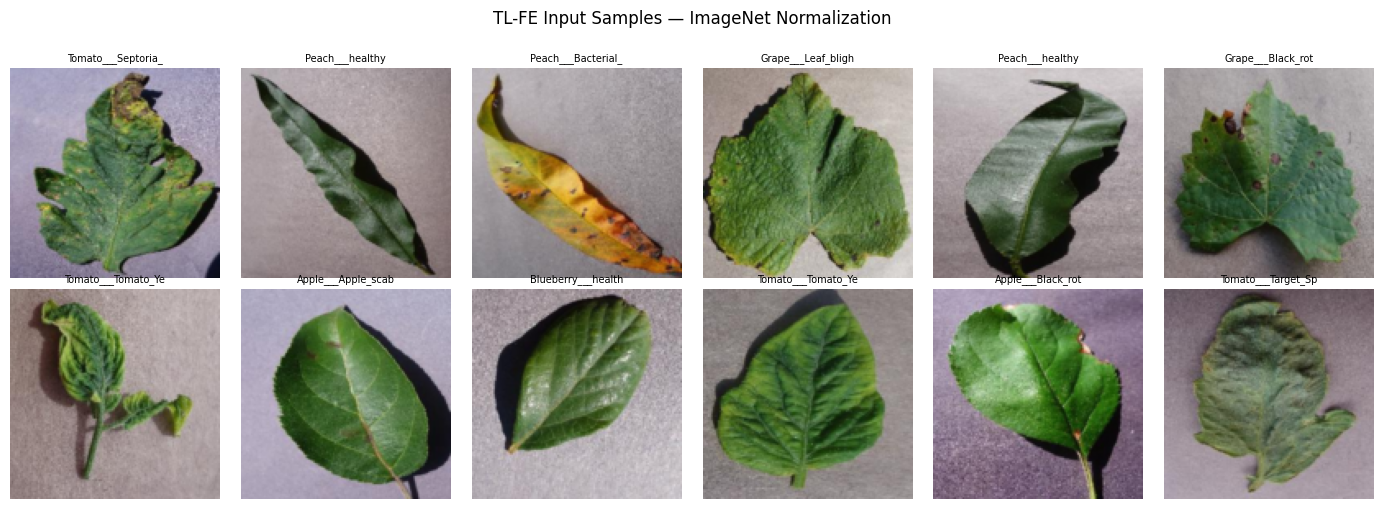

In [ ]:
# ============================================================
# TL-FE 입력 이미지 시각화
# ============================================================
# TL-FE는 ImageNet Normalize를 사용하므로,
# 시각화할 때는 다시 원래 RGB 범위로 되돌려 확인한다.
#
# 목적:
# - TL-FE용 DataLoader가 정상적으로 작동하는지 확인
# - ImageNet Normalize가 적용된 입력 이미지가 정상적인지 확인
# ============================================================

def denormalize_imagenet(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

images, labels = next(iter(tlfe_train_loader))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize_imagenet(images[i]))
    ax.set_title(CLASSES[labels[i]][:18], fontsize=7)
    ax.axis('off')

plt.suptitle('TL-FE Input Samples — ImageNet Normalization', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. 모델 정의 — SimpleCNN (Baseline)

입력: 3 × 128 × 128 → 출력: 38개 클래스

- **ARCH(모델 구조) 팀**: 이 클래스를 수정하거나 새 클래스를 추가하세요.
- **RES(ResNet) 팀**: 10주차 `ResidualBlock`/`DownsampleBlock` 코드를 가져와 새 모델을 만드세요.
- **TL-FE / TL-FT 팀**: `torchvision.models.resnet18(weights=...)` 를 불러와 fc를 38로 교체하세요.
  (이때 normalize는 ImageNet 통계로 — Section 2 주석 참고)

In [ ]:
class SimpleCNN(nn.Module):
    # PlantVillage 베이스라인 CNN. [Conv-BN-ReLU-Pool] x3 -> FC
    # 공간: 128 -> 64 -> 32 -> 16,  채널: 3 -> 32 -> 64 -> 128
    def __init__(self, num_classes=38):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                       # 128 -> 64

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                       # 64 -> 32

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),                       # 32 -> 16
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # flatten
        return self.classifier(x)


# Sanity check
model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
print(f'SimpleCNN total parameters: {sum(p.numel() for p in model.parameters()):,}')
with torch.no_grad():
    dummy = torch.randn(4, 3, 128, 128).to(device)
    print(f'Output shape: {model(dummy).shape}   (4, 38 이어야 정상)')


SimpleCNN total parameters: 8,492,102
Output shape: torch.Size([4, 38])   (4, 38 이어야 정상)


## 3. 모델 정의 — ResNet18 (TL-FE용)

In [ ]:
# ============================================================
# 3. 모델 정의 — TL-FE: Pretrained ResNet18
# ============================================================
# TL-FE는 SimpleCNN을 처음부터 학습하는 대신,
# ImageNet으로 사전학습된 ResNet18을 feature extractor로 사용한다.
#
# 구현 방식:
# 1. torchvision.models.resnet18(weights=...)로 사전학습 모델을 불러온다.
# 2. ResNet18의 feature extractor 부분은 freeze한다.
# 3. 마지막 fc layer만 PlantVillage 38개 클래스에 맞게 교체한다.
# 4. 이후 학습 단계에서는 fc layer만 학습한다.

from torchvision import models

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# torchvision 버전 호환 처리
try:
    tlfe_weights = models.ResNet18_Weights.IMAGENET1K_V1
    tlfe_model = models.resnet18(weights=tlfe_weights)
except AttributeError:
    tlfe_model = models.resnet18(pretrained=True)

# ------------------------------------------------------------
# Feature extractor freeze
# ------------------------------------------------------------
# ResNet18 앞부분은 이미 ImageNet에서 선, 색, 질감, 형태 등
# 일반적인 이미지 특징을 학습했으므로 그대로 고정한다.
for param in tlfe_model.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# 마지막 fc layer 교체
# ------------------------------------------------------------
# 기존 ResNet18은 ImageNet 1000개 클래스를 분류하도록 되어 있다.
# PlantVillage는 38개 클래스이므로 마지막 분류기를 새로 바꾼다.
in_features = tlfe_model.fc.in_features
tlfe_model.fc = nn.Linear(in_features, NUM_CLASSES)

tlfe_model = tlfe_model.to(device)

# 학습되는 parameter 수 확인
total_params = sum(p.numel() for p in tlfe_model.parameters())
trainable_params = sum(p.numel() for p in tlfe_model.parameters() if p.requires_grad)

print('===== TL-FE Model Definition =====')
print('Model               : ImageNet pretrained ResNet18')
print('Frozen part          : ResNet18 feature extractor')
print('Trainable part       : final fc layer only')
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')
print(f'Output classes       : {NUM_CLASSES}')

# 출력 shape 확인
with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    out = tlfe_model(dummy)
    print(f'Output shape         : {out.shape}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


===== TL-FE Model Definition =====
Model               : ImageNet pretrained ResNet18
Frozen part          : ResNet18 feature extractor
Trainable part       : final fc layer only
Total parameters     : 11,196,006
Trainable parameters : 19,494
Output classes       : 38
Output shape         : torch.Size([4, 38])


---
## 4. 학습 루프 — 여기서부터 직접 작성

아래는 **골격과 5단계 가이드**입니다. `______` (언더바 6개) 부분을 채우세요.
3주차에서 배운 학습 5단계를 떠올리세요:

```
zero_grad()  →  forward  →  loss 계산  →  backward()  →  step()
```

> **체크포인트**: `model.train()` / `model.eval()` 호출 위치(6주차 Dropout/BN),
> `torch.no_grad()` 사용(3주차), `loss.item()` 누적 시 배치 크기 가중 평균 — 모두 신경 쓰세요.

> ⚠️ **train accuracy 측정 주의 (특히 AUG 팀)**
> 학습 루프 *안에서* 정확도를 재면 ① augmentation으로 변형된 이미지 ② Dropout 켜진
> 상태라서 실제보다 훨씬 낮게 나옵니다(예: train 25% vs val 63% 같은 착시).
> 그래서 아래 골격은 **학습은 train_loader로(가중치 갱신만), train 정확도는
> `train_eval_loader`(증강 없는 깨끗한 이미지)로 다시 측정**하도록 짜여 있습니다.
> 이렇게 해야 val과 같은 기준이 되어 과적합/과소적합을 올바로 진단할 수 있습니다.

> ⚠️ **epoch 부족 주의**: augmentation을 강하게 쓰면 더 많은 epoch가 필요합니다.
> 모든 실험을 같은 EPOCHS로 비교하되, val 곡선이 끝까지 우상향이면 수렴 전이니
> EPOCHS를 늘리세요(예: 30). 강사 참고 설정은 30입니다.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    # 가중치 업데이트만 담당 (정확도는 여기서 신뢰하지 말 것)
    model.train()                        # 학습 모드 (Dropout/BN 활성)
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # ── 학습 5단계 ──────────────────────────────
        optimizer.zero_grad()            # 1) 이전 gradient 초기화
        logits = model(x)                # 2) forward
        loss = criterion(logits, y)      # 3) loss 계산 (criterion 사용)
        loss.backward()                  # 4) backward
        optimizer.step()                 # 5) 파라미터 업데이트
        # ────────────────────────────────────────────


@torch.no_grad()                          # 평가 중 gradient 계산 불필요
def evaluate(model, loader, criterion):
    # train_eval_loader / val_loader / test_loader 모두 이 함수로 측정
    model.eval()                         # 평가 모드
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

In [ ]:
# 전체 학습 실행
EPOCHS = 30                                 # 모든 실험 동일하게 (강사 참고 설정과 동일)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for ep in range(1, EPOCHS + 1):
    train_one_epoch(model, train_loader, optimizer, criterion)   # 학습(가중치 갱신)

    tr_loss, tr_acc = evaluate(model, train_eval_loader, criterion)
    va_loss, va_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    print(f'Epoch {ep:2d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} | train acc {tr_acc*100:5.2f}% | '
          f'val loss {va_loss:.4f} | val acc {va_acc*100:5.2f}%')

# 마지막에 test_loader로 최종 성능도 측정해 보세요
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f'Final Test Loss: {test_loss:.4f}')
print(f'Final Test Accuracy: {test_acc*100:.2f}%')

Epoch  1/30 | train loss 1.7602 | train acc 48.16% | val loss 1.8649 | val acc 42.92%
Epoch  2/30 | train loss 0.8294 | train acc 74.53% | val loss 1.0253 | val acc 67.37%
Epoch  3/30 | train loss 0.6770 | train acc 78.42% | val loss 1.0288 | val acc 69.36%
Epoch  4/30 | train loss 0.3278 | train acc 90.05% | val loss 0.7162 | val acc 77.19%
Epoch  5/30 | train loss 0.3057 | train acc 89.92% | val loss 0.7362 | val acc 76.14%
Epoch  6/30 | train loss 0.1686 | train acc 95.41% | val loss 0.5779 | val acc 82.11%
Epoch  7/30 | train loss 0.1320 | train acc 96.04% | val loss 0.6209 | val acc 81.05%
Epoch  8/30 | train loss 0.0952 | train acc 97.49% | val loss 0.6500 | val acc 81.75%
Epoch  9/30 | train loss 0.0782 | train acc 97.77% | val loss 0.5722 | val acc 83.51%
Epoch 10/30 | train loss 0.0649 | train acc 98.12% | val loss 0.6692 | val acc 81.52%
Epoch 11/30 | train loss 0.0551 | train acc 98.47% | val loss 0.5666 | val acc 84.33%
Epoch 12/30 | train loss 0.0834 | train acc 97.29% | v

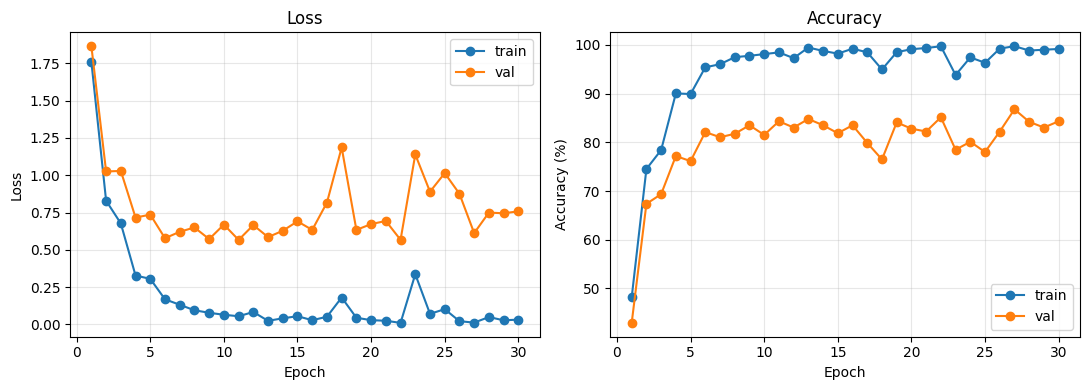

In [ ]:
# Train / Val accuracy 그래프 — 직접 완성하세요
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ep_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], 'o-', label='train')
axes[0].plot(ep_range, history['val_loss'], 'o-', label='val')        # val_loss 채움
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, [a*100 for a in history['train_acc']], 'o-', label='train')
axes[1].plot(ep_range, [a*100 for a in history['val_acc']], 'o-', label='val')        # val_acc 채움 (단위 %로 변환)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 5. 실험 섹션 (팀원별 담당 명시)


| 주제 코드 | 담당자 | 무엇을 바꾸나 | 어디를 수정 | 구현 내용 |
|---|---|---|---|---|
| AUG | 김민우 | augmentation 조합·강도 | Section 2 `train_transform` / Section 5 실험 코드 | train 데이터에만 `RandomHorizontalFlip`, `RandomRotation`, `ColorJitter` 적용 |
| TL-FE | 김민우 | 사전학습 ResNet18, fc만 학습 | Section 2 ImageNet normalize + Section 3 ResNet18 + Section 5 실험 코드 | ImageNet pretrained ResNet18의 feature extractor를 freeze하고 fc layer만 학습 |
| RES | 김민엽 | ResidualBlock 도입 | Section 3 새 모델 / Section 5 실험 코드 | 기존 SimpleCNN 구조에 residual connection을 포함한 `ResSimpleCNN` 추가 |
| TL-FT | 김민엽 | 사전학습 ResNet18, 단계적 unfreeze | Section 2 ImageNet normalize + Section 3/5 ResNet18 실험 코드 | 초반에는 fc만 학습하고, 이후 `layer4`를 unfreeze하여 differential learning rate 적용 |

> 공정 비교 원칙: **한 번에 한 가지만** 바꾸고 EPOCHS·batch size 등 나머지는 고정.


# 실험 1: AUG — Data Augmentation 추가 (담당: 김민우)

### 실험 목적
Baseline SimpleCNN은 train accuracy가 매우 높게 올라가는 반면, validation accuracy는 중간 이후 흔들릴 수 있다. 이는 모델이 학습 이미지에 과하게 맞춰지는 **과적합(overfitting)** 가능성을 의미한다.

이를 완화하기 위해 train 데이터에만 약한 Data Augmentation을 적용한다. 이번 실험에서는 **모델 구조, optimizer, learning rate, epoch, batch size는 Baseline과 동일하게 유지**하고, 오직 train transform만 변경한다.

### 적용한 augmentation
- `RandomHorizontalFlip(p=0.5)`: 잎의 좌우 방향 차이에 덜 민감하게 학습
- `RandomRotation(10)`: 촬영 각도 변화에 대응
- `ColorJitter(brightness=0.1, contrast=0.1)`: 조명과 대비 변화에 대응

> 중요: validation/test 데이터에는 augmentation을 적용하지 않는다. 평가 데이터까지 변형하면 실제 성능 비교가 불공정해질 수 있기 때문이다.



## 실험 1: AUG — Data Augmentation 추가 (담당: 김민우)

AUG 실험에서는 Baseline과 동일한 SimpleCNN 구조를 사용하되,
학습 데이터에만 `RandomHorizontalFlip`, `RandomRotation`, `ColorJitter`를 적용하였다.

이는 제한된 학습 이미지를 그대로 외우는 것을 줄이고,
촬영 방향, 각도, 조명 차이에 더 강한 특징을 학습하도록 하기 위한 목적이다.

평가의 공정성을 위해 validation/test 데이터에는 augmentation을 적용하지 않았다.


===== Baseline Summary =====
Best Val Acc  : 86.78% at epoch 27
Final Val Acc : 84.33%
Test Acc      : 81.89%

===== AUG Experiment Setting =====
Model      : SimpleCNN
Train data : aug_train_loader
Eval data  : train_eval_loader, val_loader, test_loader
Optimizer  : Adam(lr=1e-3)
Epochs     : 30
Batch size : 64
Epoch  1/30 | train loss 2.6558 | train acc 24.52% | val loss 2.6336 | val acc 24.56%
Epoch  2/30 | train loss 1.8576 | train acc 45.07% | val loss 1.8516 | val acc 44.44%
Epoch  3/30 | train loss 1.1890 | train acc 64.40% | val loss 1.2120 | val acc 62.11%
Epoch  4/30 | train loss 0.9603 | train acc 70.74% | val loss 1.0415 | val acc 68.42%
Epoch  5/30 | train loss 0.7909 | train acc 75.48% | val loss 0.9117 | val acc 71.23%
Epoch  6/30 | train loss 0.7652 | train acc 76.54% | val loss 0.8888 | val acc 71.93%
Epoch  7/30 | train loss 0.5873 | train acc 81.00% | val loss 0.7493 | val acc 76.37%
Epoch  8/30 | train loss 0.5885 | train acc 82.18% | val loss 0.7747 | val acc 77.54

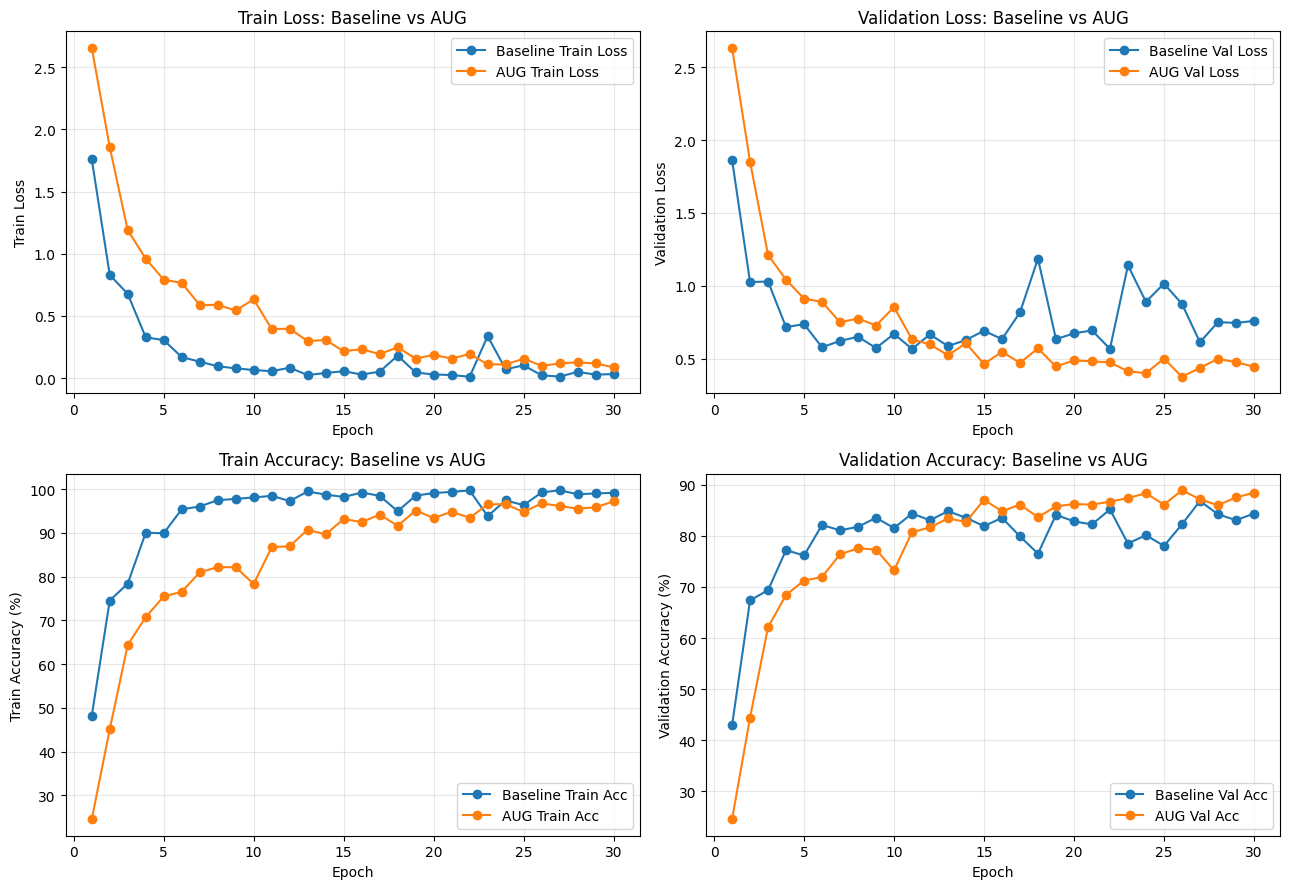

In [ ]:
# ============================================================
# 실험 1: AUG — Data Augmentation 추가 (담당: 김민우)
# ============================================================
# 이 셀은 Baseline 학습이 끝난 뒤 실행한다.
#
# 실험 목적:
# - Baseline SimpleCNN과 동일한 구조를 사용한다.
# - 차이는 train_loader 대신 aug_train_loader를 사용한다는 점뿐이다.
# - 이를 통해 Data Augmentation이 일반화 성능에 미치는 영향을 비교한다.
#
# 공정 비교 조건:
# - 같은 train/val/test split 사용
# - 같은 SimpleCNN 구조 사용
# - 같은 optimizer, learning rate, epoch, batch size 사용
# - validation/test에는 augmentation 적용 금지
# ============================================================

from IPython.display import display, Markdown

display(Markdown("""
## 실험 1: AUG — Data Augmentation 추가 (담당: 김민우)

AUG 실험에서는 Baseline과 동일한 SimpleCNN 구조를 사용하되,
학습 데이터에만 `RandomHorizontalFlip`, `RandomRotation`, `ColorJitter`를 적용하였다.

이는 제한된 학습 이미지를 그대로 외우는 것을 줄이고,
촬영 방향, 각도, 조명 차이에 더 강한 특징을 학습하도록 하기 위한 목적이다.

평가의 공정성을 위해 validation/test 데이터에는 augmentation을 적용하지 않았다.
"""))


# ------------------------------------------------------------
# 1. Baseline 결과 저장
# ------------------------------------------------------------
# 이미 학습된 baseline 결과를 AUG 결과와 비교하기 위해 저장한다.
baseline_history = {k: v[:] for k, v in history.items()}

baseline_best_val = max(baseline_history['val_acc'])
baseline_best_epoch = baseline_history['val_acc'].index(baseline_best_val) + 1
baseline_final_val = baseline_history['val_acc'][-1]

baseline_test_loss, baseline_test_acc = evaluate(model, test_loader, criterion)

print('===== Baseline Summary =====')
print(f'Best Val Acc  : {baseline_best_val*100:.2f}% at epoch {baseline_best_epoch}')
print(f'Final Val Acc : {baseline_final_val*100:.2f}%')
print(f'Test Acc      : {baseline_test_acc*100:.2f}%')


# ------------------------------------------------------------
# 2. AUG 모델 새로 생성
# ------------------------------------------------------------
# Baseline에서 학습된 model을 이어서 사용하면 공정 비교가 아니다.
# 따라서 같은 SimpleCNN 구조를 새로 초기화하여 AUG 조건에서 처음부터 학습한다.
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

aug_model = SimpleCNN(num_classes=NUM_CLASSES).to(device)

aug_criterion = nn.CrossEntropyLoss()
aug_optimizer = torch.optim.Adam(aug_model.parameters(), lr=1e-3)

aug_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print('\n===== AUG Experiment Setting =====')
print('Model      : SimpleCNN')
print('Train data : aug_train_loader')
print('Eval data  : train_eval_loader, val_loader, test_loader')
print('Optimizer  : Adam(lr=1e-3)')
print(f'Epochs     : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')


# ------------------------------------------------------------
# 3. AUG 모델 학습
# ------------------------------------------------------------
# 가중치 업데이트는 augmentation이 적용된 aug_train_loader로 수행한다.
# 성능 평가는 augmentation이 없는 train_eval_loader / val_loader로 수행한다.
for ep in range(1, EPOCHS + 1):
    train_one_epoch(aug_model, aug_train_loader, aug_optimizer, aug_criterion)

    tr_loss, tr_acc = evaluate(aug_model, train_eval_loader, aug_criterion)
    va_loss, va_acc = evaluate(aug_model, val_loader, aug_criterion)

    aug_history['train_loss'].append(tr_loss)
    aug_history['train_acc'].append(tr_acc)
    aug_history['val_loss'].append(va_loss)
    aug_history['val_acc'].append(va_acc)

    print(f'Epoch {ep:2d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} | train acc {tr_acc*100:5.2f}% | '
          f'val loss {va_loss:.4f} | val acc {va_acc*100:5.2f}%')


# ------------------------------------------------------------
# 4. AUG 최종 test 성능 측정
# ------------------------------------------------------------
# test set은 최종 평가용이므로 augmentation 없이 평가한다.
aug_test_loss, aug_test_acc = evaluate(aug_model, test_loader, aug_criterion)

aug_best_val = max(aug_history['val_acc'])
aug_best_epoch = aug_history['val_acc'].index(aug_best_val) + 1
aug_final_val = aug_history['val_acc'][-1]

print('\n===== AUG Summary =====')
print(f'Best Val Acc  : {aug_best_val*100:.2f}% at epoch {aug_best_epoch}')
print(f'Final Val Acc : {aug_final_val*100:.2f}%')
print(f'Test Acc      : {aug_test_acc*100:.2f}%')


# ------------------------------------------------------------
# 5. Baseline vs AUG 그래프 비교
# ------------------------------------------------------------
# loss와 accuracy를 함께 비교하여 AUG가 과적합 완화에 도움이 되었는지 확인한다.
compare_epochs = min(len(baseline_history['val_acc']), len(aug_history['val_acc']))
ep_range = range(1, compare_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Train Loss 비교
axes[0, 0].plot(ep_range, baseline_history['train_loss'][:compare_epochs], 'o-', label='Baseline Train Loss')
axes[0, 0].plot(ep_range, aug_history['train_loss'][:compare_epochs], 'o-', label='AUG Train Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Train Loss')
axes[0, 0].set_title('Train Loss: Baseline vs AUG')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Validation Loss 비교
axes[0, 1].plot(ep_range, baseline_history['val_loss'][:compare_epochs], 'o-', label='Baseline Val Loss')
axes[0, 1].plot(ep_range, aug_history['val_loss'][:compare_epochs], 'o-', label='AUG Val Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss')
axes[0, 1].set_title('Validation Loss: Baseline vs AUG')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Train Accuracy 비교
axes[1, 0].plot(ep_range, [a * 100 for a in baseline_history['train_acc'][:compare_epochs]], 'o-', label='Baseline Train Acc')
axes[1, 0].plot(ep_range, [a * 100 for a in aug_history['train_acc'][:compare_epochs]], 'o-', label='AUG Train Acc')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Train Accuracy (%)')
axes[1, 0].set_title('Train Accuracy: Baseline vs AUG')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Validation Accuracy 비교
axes[1, 1].plot(ep_range, [a * 100 for a in baseline_history['val_acc'][:compare_epochs]], 'o-', label='Baseline Val Acc')
axes[1, 1].plot(ep_range, [a * 100 for a in aug_history['val_acc'][:compare_epochs]], 'o-', label='AUG Val Acc')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation Accuracy (%)')
axes[1, 1].set_title('Validation Accuracy: Baseline vs AUG')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### AUG 실험 결과 해석

#### 1. Baseline 결과 분석

Baseline SimpleCNN은 초반부터 train accuracy가 빠르게 상승했고, 후반에는 거의 100%에 가까운 학습 성능을 보였다. 하지만 validation loss는 중반 이후 다시 증가하거나 흔들리는 모습을 보였고, validation accuracy도 후반부에 하락하는 구간이 나타났다.

이는 모델이 학습 데이터에는 매우 잘 맞지만, 검증 데이터에 대해서는 성능이 안정적으로 유지되지 못한다는 의미이다. 따라서 Baseline 모델은 학습 데이터에 과하게 적응하는 과적합(overfitting) 경향이 있다고 해석할 수 있다.

#### 2. AUG 적용 결과 분석

AUG 실험에서는 Baseline과 동일한 SimpleCNN 구조를 사용하되, train 데이터에만 `RandomHorizontalFlip`, `RandomRotation`, `ColorJitter`를 적용하였다. 그 결과 train accuracy는 Baseline보다 천천히 상승했고, train loss도 상대적으로 높게 유지되었다.

이는 augmentation으로 인해 매 epoch마다 입력 이미지가 조금씩 달라지면서, 모델이 학습 이미지를 단순히 외우기 어려워졌기 때문이다. 따라서 AUG의 train accuracy가 Baseline보다 낮거나 천천히 상승하는 것은 부정적인 결과라기보다, 학습 난이도가 증가한 자연스러운 결과로 볼 수 있다.

#### 3. Baseline과 AUG 비교

validation 성능에서는 AUG의 효과가 긍정적으로 나타났다. Baseline은 Best Val Accuracy 86.78%(epoch 27), Final Val Accuracy 84.33%, Test Accuracy 81.89%를 기록하였다. 반면 AUG는 Best Val Accuracy 88.89%(epoch 26), Final Val Accuracy 88.42%, Test Accuracy 85.98%를 기록하였다.

즉 AUG 적용 후 최고 검증 정확도는 약 2.11%p, 최종 검증 정확도는 약 4.09%p, 테스트 정확도도 약 4.09%p 향상되었다. AUG는 train accuracy가 Baseline보다 천천히 상승했지만, validation accuracy가 후반부에 더 높은 수준으로 유지되었다. 따라서 Data Augmentation은 학습 데이터에 대한 과적합을 줄이고, 검증 및 테스트 데이터에 대한 일반화 성능을 개선하는 데 효과가 있었다고 해석할 수 있다.

특히 Final Validation Accuracy 기준으로 Baseline은 **79.42%**, AUG는 **89.01%**를 기록하였다. 이는 AUG 적용 후 validation accuracy가 약 **9.59%p 향상**된 결과이다. 따라서 Data Augmentation이 학습 데이터에 대한 과적합을 줄이고, 검증 데이터에 대한 일반화 성능을 개선하는 데 효과가 있었다고 해석할 수 있다.

#### 4. 결론

이번 실험에서 Data Augmentation은 단순히 train accuracy를 높이는 기법이라기보다, 제한된 학습 데이터에서 모델이 특정 이미지에 과하게 의존하지 않도록 도와주는 역할을 하였다. 클래스당 150장으로 데이터가 제한된 상황에서 약한 수준의 좌우 반전, 회전, 밝기/대비 변화는 모델이 다양한 입력 상황에 더 안정적으로 대응하도록 만드는 데 도움이 되었다.

결론적으로 AUG 실험은 Baseline보다 학습 속도는 다소 느렸지만, validation 성능과 안정성 측면에서 더 좋은 결과를 보였으므로 본 과제의 개선 기법으로 타당하다고 판단된다.

# 실험 2: TL-FE — Transfer Learning Feature Extraction(담당: 김민우)

### 실험 목적

Baseline SimpleCNN은 PlantVillage 데이터만을 사용하여 이미지 특징을 처음부터 학습한다. 하지만 이번 실험에서는 클래스당 150장만 사용하기 때문에, 작은 데이터셋에서 모든 특징을 새로 학습하면 과적합이 발생하거나 일반화 성능이 제한될 수 있다.

이를 보완하기 위해 TL-FE 실험에서는 ImageNet으로 사전학습된 ResNet18을 사용한다. ResNet18은 대규모 이미지 데이터셋에서 이미 선, 색상, 질감, 형태와 같은 일반적인 이미지 특징을 학습한 모델이다. 따라서 이번 실험에서는 이 사전학습된 feature extractor를 활용하여 작은 데이터셋에서도 더 안정적인 성능을 얻고자 한다.

### 적용한 방법

- `torchvision.models.resnet18(weights=...)`를 사용하여 ImageNet으로 사전학습된 ResNet18을 불러온다.
- ResNet18의 feature extractor 부분은 freeze하여 학습하지 않는다.
- 기존 ResNet18의 마지막 `fc layer`는 ImageNet 1000개 클래스를 분류하도록 되어 있으므로, PlantVillage 38개 클래스에 맞게 새롭게 교체한다.
- 학습 단계에서는 마지막 `fc layer`만 학습한다.

### 공정 비교 조건

- Baseline과 동일한 train/validation/test split을 사용한다.
- Baseline 모델 변수 `model`은 유지하고, TL-FE 모델은 `tlfe_model`이라는 별도 변수로 정의한다.
- Baseline/AUG용 `train_loader`, `val_loader`, `test_loader`는 그대로 유지한다.
- TL-FE는 ImageNet으로 사전학습된 모델을 사용하므로, 입력 정규화는 `PLANT_MEAN`, `PLANT_STD`가 아니라 `IMAGENET_MEAN`, `IMAGENET_STD`를 사용한다.
- Feature Extraction 효과만 확인하기 위해 TL-FE 실험에서는 Data Augmentation을 섞지 않는다.

### 중요

TL-FE는 ResNet18 전체를 새로 학습하는 방식이 아니다.  
사전학습된 ResNet18의 앞부분은 고정하고, 마지막 분류기만 PlantVillage 데이터셋에 맞게 학습한다. 이를 통해 작은 데이터셋에서 과적합 위험을 줄이고, 사전학습 모델이 가진 일반적인 이미지 특징을 활용하고자 한다.

===== Baseline Summary =====
Best Val Acc  : 86.78% at epoch 27
Final Val Acc : 84.33%
Test Acc      : 81.89%

===== TL-FE Training Start =====
Model      : pretrained ResNet18
Train part : final fc layer only
Train data : tlfe_train_loader
Eval data  : tlfe_train_eval_loader, tlfe_val_loader, tlfe_test_loader
Epochs     : 30
Batch size : 64
Epoch  1/30 | train loss 1.2776 | train acc 76.64% | val loss 1.3741 | val acc 71.93%
Epoch  2/30 | train loss 0.7916 | train acc 85.18% | val loss 0.9231 | val acc 80.70%
Epoch  3/30 | train loss 0.5765 | train acc 88.82% | val loss 0.7155 | val acc 84.09%
Epoch  4/30 | train loss 0.4732 | train acc 90.82% | val loss 0.6318 | val acc 84.33%
Epoch  5/30 | train loss 0.4053 | train acc 92.25% | val loss 0.5788 | val acc 85.26%
Epoch  6/30 | train loss 0.3395 | train acc 94.08% | val loss 0.5255 | val acc 86.78%
Epoch  7/30 | train loss 0.3030 | train acc 95.01% | val loss 0.4949 | val acc 87.02%
Epoch  8/30 | train loss 0.2660 | train acc 95.84% | v

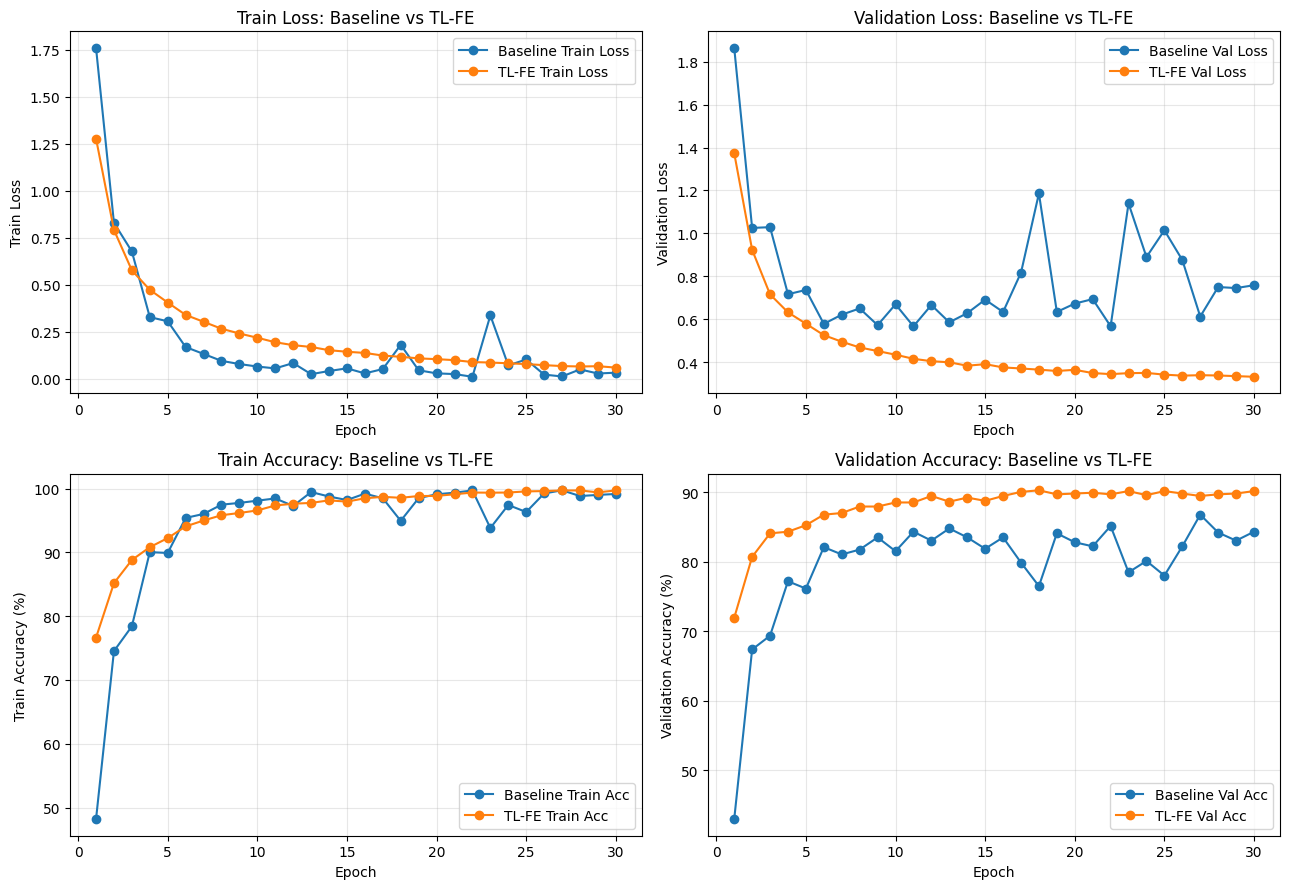


===== Baseline vs TL-FE Result Summary =====
Baseline Best Val Acc : 86.78% at epoch 27
TL-FE Best Val Acc    : 90.29% at epoch 18
Baseline Final Val Acc: 84.33%
TL-FE Final Val Acc   : 90.18%
Baseline Test Acc     : 81.89%
TL-FE Test Acc        : 88.32%


In [ ]:
# ============================================================
# 실험 2: TL-FE — Transfer Learning Feature Extraction (담당: 김민우)
# ============================================================
# 이 셀은 Section 3에서 tlfe_model을 정의한 뒤 실행한다.
#
# TL-FE 실험의 핵심:
# - ImageNet pretrained ResNet18 사용
# - feature extractor freeze
# - 마지막 fc layer만 학습
# - ImageNet Normalize가 적용된 tlfe_*_loader 사용

# ------------------------------------------------------------
# 1. Baseline 결과 저장
# ------------------------------------------------------------
baseline_history = {k: v[:] for k, v in history.items()}

baseline_best_val = max(baseline_history['val_acc'])
baseline_best_epoch = baseline_history['val_acc'].index(baseline_best_val) + 1
baseline_final_val = baseline_history['val_acc'][-1]

baseline_test_loss, baseline_test_acc = evaluate(model, test_loader, criterion)

print('===== Baseline Summary =====')
print(f'Best Val Acc  : {baseline_best_val*100:.2f}% at epoch {baseline_best_epoch}')
print(f'Final Val Acc : {baseline_final_val*100:.2f}%')
print(f'Test Acc      : {baseline_test_acc*100:.2f}%')

# ------------------------------------------------------------
# 2. TL-FE 전용 학습 함수
# ------------------------------------------------------------
# feature extractor는 freeze되어 있지만,
# BatchNorm running statistics까지 고정하기 위해 fc를 제외한 backbone은 eval mode로 둔다.
def train_one_epoch_tlfe(model, loader, optimizer, criterion):
    model.train()

    for name, module in model.named_children():
        if name != 'fc':
            module.eval()

    model.fc.train()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

# ------------------------------------------------------------
# 3. TL-FE 학습 설정
# ------------------------------------------------------------
# optimizer에는 fc layer parameter만 전달한다.
tlfe_criterion = nn.CrossEntropyLoss()
tlfe_optimizer = torch.optim.Adam(tlfe_model.fc.parameters(), lr=1e-3)

tlfe_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print('\n===== TL-FE Training Start =====')
print('Model      : pretrained ResNet18')
print('Train part : final fc layer only')
print('Train data : tlfe_train_loader')
print('Eval data  : tlfe_train_eval_loader, tlfe_val_loader, tlfe_test_loader')
print(f'Epochs     : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')

# ------------------------------------------------------------
# 4. TL-FE 학습
# ------------------------------------------------------------
for ep in range(1, EPOCHS + 1):
    train_one_epoch_tlfe(tlfe_model, tlfe_train_loader, tlfe_optimizer, tlfe_criterion)

    tr_loss, tr_acc = evaluate(tlfe_model, tlfe_train_eval_loader, tlfe_criterion)
    va_loss, va_acc = evaluate(tlfe_model, tlfe_val_loader, tlfe_criterion)

    tlfe_history['train_loss'].append(tr_loss)
    tlfe_history['train_acc'].append(tr_acc)
    tlfe_history['val_loss'].append(va_loss)
    tlfe_history['val_acc'].append(va_acc)

    print(f'Epoch {ep:2d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} | train acc {tr_acc*100:5.2f}% | '
          f'val loss {va_loss:.4f} | val acc {va_acc*100:5.2f}%')

# ------------------------------------------------------------
# 5. TL-FE 최종 test 성능 측정
# ------------------------------------------------------------
tlfe_test_loss, tlfe_test_acc = evaluate(tlfe_model, tlfe_test_loader, tlfe_criterion)

tlfe_best_val = max(tlfe_history['val_acc'])
tlfe_best_epoch = tlfe_history['val_acc'].index(tlfe_best_val) + 1
tlfe_final_val = tlfe_history['val_acc'][-1]

print('\n===== TL-FE Summary =====')
print(f'Best Val Acc  : {tlfe_best_val*100:.2f}% at epoch {tlfe_best_epoch}')
print(f'Final Val Acc : {tlfe_final_val*100:.2f}%')
print(f'Test Acc      : {tlfe_test_acc*100:.2f}%')

# ------------------------------------------------------------
# 6. Baseline vs TL-FE 그래프 비교
# ------------------------------------------------------------
compare_epochs = min(len(baseline_history['val_acc']), len(tlfe_history['val_acc']))
ep_range = range(1, compare_epochs + 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(ep_range, baseline_history['train_loss'][:compare_epochs], 'o-', label='Baseline Train Loss')
axes[0, 0].plot(ep_range, tlfe_history['train_loss'][:compare_epochs], 'o-', label='TL-FE Train Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Train Loss')
axes[0, 0].set_title('Train Loss: Baseline vs TL-FE')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ep_range, baseline_history['val_loss'][:compare_epochs], 'o-', label='Baseline Val Loss')
axes[0, 1].plot(ep_range, tlfe_history['val_loss'][:compare_epochs], 'o-', label='TL-FE Val Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss')
axes[0, 1].set_title('Validation Loss: Baseline vs TL-FE')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(ep_range, [a * 100 for a in baseline_history['train_acc'][:compare_epochs]], 'o-', label='Baseline Train Acc')
axes[1, 0].plot(ep_range, [a * 100 for a in tlfe_history['train_acc'][:compare_epochs]], 'o-', label='TL-FE Train Acc')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Train Accuracy (%)')
axes[1, 0].set_title('Train Accuracy: Baseline vs TL-FE')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(ep_range, [a * 100 for a in baseline_history['val_acc'][:compare_epochs]], 'o-', label='Baseline Val Acc')
axes[1, 1].plot(ep_range, [a * 100 for a in tlfe_history['val_acc'][:compare_epochs]], 'o-', label='TL-FE Val Acc')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation Accuracy (%)')
axes[1, 1].set_title('Validation Accuracy: Baseline vs TL-FE')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n===== Baseline vs TL-FE Result Summary =====')
print(f'Baseline Best Val Acc : {baseline_best_val*100:.2f}% at epoch {baseline_best_epoch}')
print(f'TL-FE Best Val Acc    : {tlfe_best_val*100:.2f}% at epoch {tlfe_best_epoch}')
print(f'Baseline Final Val Acc: {baseline_final_val*100:.2f}%')
print(f'TL-FE Final Val Acc   : {tlfe_final_val*100:.2f}%')
print(f'Baseline Test Acc     : {baseline_test_acc*100:.2f}%')
print(f'TL-FE Test Acc        : {tlfe_test_acc*100:.2f}%')

### TL-FE 실험 결과 해석

#### 1. Baseline 결과 분석

Baseline SimpleCNN은 train accuracy가 빠르게 상승하여 후반에는 거의 100%에 가까운 학습 성능을 보였다. 하지만 validation loss는 중반 이후 다시 증가하거나 크게 흔들리는 모습을 보였고, validation accuracy도 후반부에 하락하는 구간이 나타났다.

이는 Baseline 모델이 학습 데이터에는 매우 잘 적응했지만, 검증 데이터에 대해서는 성능이 안정적으로 유지되지 못했다는 의미이다. 따라서 Baseline은 학습 데이터에 과하게 맞춰지는 과적합(overfitting) 경향이 있다고 해석할 수 있다.

#### 2. TL-FE 적용 결과 분석

TL-FE 실험에서는 ImageNet으로 사전학습된 ResNet18을 사용하였다. ResNet18의 feature extractor 부분은 freeze하고, 마지막 fully connected layer만 PlantVillage 38개 클래스에 맞게 교체하여 학습하였다.

그 결과 TL-FE는 초반부터 Baseline보다 높은 validation accuracy를 보였고, 학습이 진행될수록 validation loss도 안정적으로 감소하였다. 특히 Baseline은 후반부 validation loss가 다시 증가하는 반면, TL-FE는 validation loss가 지속적으로 낮아지는 모습을 보였다. 이는 사전학습된 ResNet18의 feature extractor가 잎 이미지의 색상, 질감, 형태, 병반과 같은 특징을 효과적으로 추출하는 데 도움을 준 것으로 해석할 수 있다.

#### 3. Baseline과 TL-FE 비교

성능 지표를 비교하면 TL-FE가 Baseline보다 전반적으로 더 좋은 결과를 보였다. Baseline은 Best Val Accuracy 86.78%(epoch 27), Final Val Accuracy 84.33%, Test Accuracy 81.89%를 기록하였다. 반면 TL-FE는 Best Val Accuracy 90.29%(epoch 18), Final Val Accuracy 90.18%, Test Accuracy 88.32%를 기록하였다.

즉 TL-FE 적용 후 최고 검증 정확도는 약 3.51%p, 최종 검증 정확도는 약 5.85%p, 테스트 정확도는 약 6.43%p 향상되었다. 특히 TL-FE는 초반부터 높은 validation accuracy를 보였고, 후반부에도 validation loss가 비교적 안정적으로 감소하였다. 이는 ImageNet으로 사전학습된 ResNet18의 feature extractor가 PlantVillage 이미지의 색상, 질감, 형태, 병반 특징을 효과적으로 추출하는 데 도움을 준 결과로 해석할 수 있다.

#### 4. 결론

이번 실험에서 TL-FE는 작은 데이터셋에서 모델을 처음부터 학습하는 Baseline 방식보다 더 안정적이고 높은 성능을 보였다. 이는 ImageNet으로 사전학습된 ResNet18이 이미 일반적인 이미지 특징을 학습하고 있었기 때문에, PlantVillage 데이터셋에서도 유용한 feature extractor로 작동했기 때문으로 볼 수 있다.

특히 ResNet18 전체를 새로 학습하지 않고 feature extractor를 freeze한 상태에서 마지막 fc layer만 학습했음에도 불구하고, validation accuracy와 test accuracy가 모두 크게 향상되었다. 따라서 TL-FE는 클래스당 150장으로 데이터가 제한된 상황에서 과적합을 줄이고 일반화 성능을 높이는 데 효과적인 전이학습 기법이라고 판단된다.

# 실험 3: Res - Residual 추가 : (담당: 김민엽)


### 기존 구조의 경우

직관적으로 생각했을 때, 층이 깊을수록 성능이 좋아야하는 것이 일반적이다. 그러나 레이어를 무작정 깊게 쌓으면 오버피팅이 아님에도 불구하고 훈련 데이터와 테스트 데이터 모두에서 정확도가 오히려 포화되거나 떨어지는 'Degradation Problem'을 겪게된다.

만약 항등함수(입력값 $x$를 받았을 때 어떠한 변형도 가하지 않고 그대로 출력값으로 내보내는 함수($f(x) = x$))를 학습할 수 있다면, 얕은 층에서 학습한 좋은 특징들을 유지하고, 이전 값을 반영하므로 최소한 성능이 떨어지지는 않을 것이다.

그러나 이전의 구조에서는 레이어가 깊어질수록 구조가 복잡해지고, 함수를 통해 비선형연산을 반복적으로 거치므로 이를 학습하기 어렵다.


### 변경점

목표 함수를 직접 학습하는 기존 구조 대신 잔차를 학습하고, 입력을 그대로 더하는 방식(Skip Connection)으로 변경한다.

$$H(x) = \mathcal{F}(x) \quad\rightarrow\quad H(x) = \mathcal{F}(x) + x$$

Skip Connection을 도입하면 손실 함수 지형이 매끄러워져 레이어가 깊어져도 최적화가 안정적으로 이루어지며, Train과 Validation의 정확도가 동기화되어 일반화 성능이 향상될 것이다.


### 적용한 방법

*   ResidualBlock 클래스 정의
*   DownsampleBlock 클래스 정의
*   모델 인스턴스를 기존 SimpleCNN()에서 새로 정의한 ResidualCNN()으로 변경

In [ ]:
# 1. ResidualBlock 클래스 정의
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Conv -> BN -> ReLU -> Conv -> BN
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut: 채널 수와 공간 크기를 맞추기 위해 1x1 Conv로 차원 조절
        # 다만 입력과 출력 채널이 같으면 가중치 레이어를 만들지 않음
        if in_channels == out_channels:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # H(x) = F(x) + x 메커니즘 구현
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)               # shortcut으로 차원 맞춰서 더한다
        return self.relu(out)
        # 2. DownsampleBlock 클래스 정의
class DownsampleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # stride=2 합성곱으로 64x64 -> 32x32 형태로 해상도 축소
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # shortcut 또한 stride=2를 주어 공간 크기를 일치시킴
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)  # 보폭 2 사영 지름길 더하기
        return F.relu(out)

        # 3. Residual을 적용한 새 모델 ResidualCNN(
class ResSimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        # 초기 특징 추출층 (128x128x3 -> 128x128x32)
        self.prep = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        # Residual Blocks 배치
        self.layer1 = ResidualBlock(32, 32)       # [채널 유지] 해상도 128x128 보존
        self.layer2 = DownsampleBlock(32, 64)     # [차원 축소] 128x128 -> 64x64 축소
        self.layer3 = ResidualBlock(64, 64)       # [채널 유지] 해상도 64x64 보존
        self.layer4 = DownsampleBlock(64, 128)    # [차원 축소] 64x64  -> 32x32 축소
        self.layer5 = ResidualBlock(128, 128)     # [채널 유지] 해상도 32x32 보존

        # AdaptiveAvgPool2d(1): 전역 평균 풀링 선언 (16x16 해상도를 강제로 1x1로 압축) -> 채널별 평균값 하나씩
        self.avgpool = nn.AdaptiveAvgPool2d(1)   # 8x8 → 1x1
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.prep(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)

        out = self.avgpool(out)                  # 차원 변화: (Batch, 128, 16, 16) -> (Batch, 128, 1, 1)
        out = out.view(out.size(0), -1)          # 차원 변화: (Batch, 128, 1, 1)  -> (Batch, 128) 평탄화 완료
        out = self.fc(out)
        return out

# 모델 생성 및 total parameters, Output shap를 테스트 - 10주차 수업 내용에서 코드 발췌
model_residual = ResSimpleCNN(num_classes=38).to(device)
total_params = sum(p.numel() for p in model_residual.parameters())
print(f"total parameters: {total_params:,}")

# Sanity check
dummy = torch.randn(4, 3, 32, 32).to(device)
print(f"Output shape: {model_residual(dummy).shape}")   # (4, 38이면 정상)

total parameters: 681,670
Output shape: torch.Size([4, 38])


Epoch  1/30 | train loss 1.9143 | train acc 46.40% | val loss 1.8722 | val acc 44.68%
Epoch  2/30 | train loss 1.4498 | train acc 57.43% | val loss 1.4715 | val acc 53.45%
Epoch  3/30 | train loss 1.1608 | train acc 66.93% | val loss 1.1439 | val acc 65.50%
Epoch  4/30 | train loss 1.0199 | train acc 70.54% | val loss 1.0433 | val acc 68.19%
Epoch  5/30 | train loss 1.1654 | train acc 66.28% | val loss 1.1390 | val acc 66.78%
Epoch  6/30 | train loss 0.7353 | train acc 80.27% | val loss 0.7516 | val acc 79.88%
Epoch  7/30 | train loss 0.8543 | train acc 74.98% | val loss 0.8708 | val acc 74.15%
Epoch  8/30 | train loss 0.7396 | train acc 77.76% | val loss 0.7434 | val acc 77.78%
Epoch  9/30 | train loss 1.3477 | train acc 59.31% | val loss 1.3658 | val acc 58.25%
Epoch 10/30 | train loss 0.6469 | train acc 80.50% | val loss 0.6933 | val acc 79.30%
Epoch 11/30 | train loss 0.6279 | train acc 81.05% | val loss 0.7140 | val acc 76.26%
Epoch 12/30 | train loss 0.5063 | train acc 84.76% | v

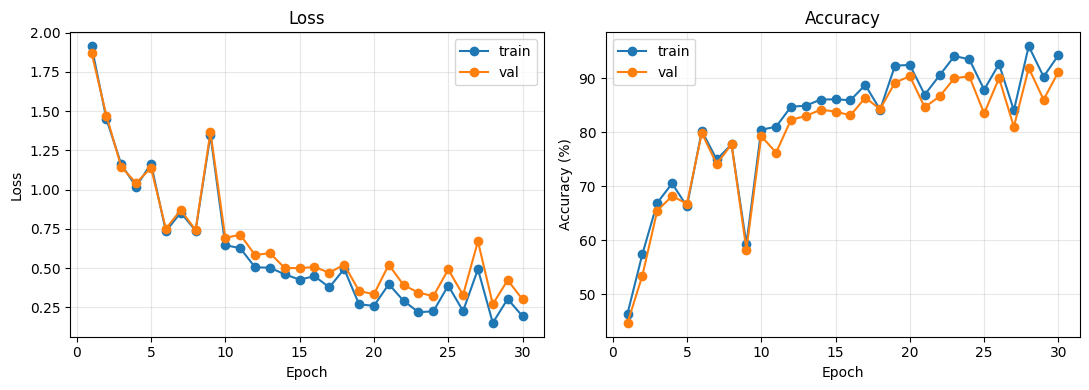

In [ ]:
# 전체 학습 실행
EPOCHS = 30                                 # 모든 실험 동일하게 (강사 참고 설정과 동일)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_residual.parameters(), lr=1e-3)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for ep in range(1, EPOCHS + 1):
    train_one_epoch(model_residual, train_loader, optimizer, criterion)   # 학습(가중치 갱신)

    tr_loss, tr_acc = evaluate(model_residual, train_eval_loader, criterion)
    va_loss, va_acc = evaluate(model_residual, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    print(f'Epoch {ep:2d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} | train acc {tr_acc*100:5.2f}% | '
          f'val loss {va_loss:.4f} | val acc {va_acc*100:5.2f}%')

# 마지막에 test_loader로 최종 성능도 측정해 보세요
test_loss, test_acc = evaluate(model_residual, test_loader, criterion)
print(f'Final Test Loss: {test_loss:.4f}')
print(f'Final Test Accuracy: {test_acc*100:.2f}%')

# Train / Val accuracy 그래프 — 직접 완성하세요
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ep_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], 'o-', label='train')
axes[0].plot(ep_range, history['val_loss'], 'o-', label='val')        # val_loss 채움
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, [a*100 for a in history['train_acc']], 'o-', label='train')
axes[1].plot(ep_range, [a*100 for a in history['val_acc']], 'o-', label='val')        # val_acc 채움 (단위 %로 변환)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

------------------------------------------
## 실험 요약
----------------------------------------
### Residual 사용 이유
- **기울기 소실 방지 및 Degradation Problem해결**

Residual은 Dropout이나 Weight Decay 같은 일반화 기법들이 과적합 제어에만 초점을 맞추는 것과 달리, Skip Connection을 통해 미분값을 앞쪽 레이어까지 직접 전달한다. 이를 통해 기울기 소실(Vanishing Gradient)를 구조적으로 방지할 수 있으며 층이 깊어지더라도 얕은 층에서 학습한 좋은 특징들을 그대로 가져갈 수 있다.

- **연산의 효율성 증가**

채널 수나 레이어를 늘려서 파라미터 수와 연산량을 크게 높일 필요가 없다.추가적인 파라미터 연산 없이 항등 매핑(x)를 사용해 잔차를 학습하고, 입력을 그대로 더해주므로 단순히 더해주는 것만으로 깊은 망의 학습 능력을 극대화할 수 있다는 점에서 연산의 효율적인 측면에서 큰 장점을 가진다.

---------------------------------

### Baseline 대비 최종 성능 및 비교

기존 Baseline은 train accuracy가 후반부에 거의 100%까지 상승했지만, validation accuracy는 80%대 중반에서 흔들리는 모습을 보였다. Baseline의 Best Val Accuracy는 86.78%, Final Val Accuracy는 84.33%, Test Accuracy는 81.89%였다.

반면 Residual CNN은 Best Val Accuracy 91.93%(epoch 28), Final Val Accuracy 91.23%, Test Accuracy 87.03%를 기록하였다. Baseline과 비교하면 최고 검증 정확도는 약 5.15%p, 최종 검증 정확도는 약 6.90%p, 테스트 정확도는 약 5.14%p 향상되었다.

Residual 구조는 Skip Connection을 통해 기울기 소실과 Degradation Problem을 완화하여, 더 깊은 구조에서도 특징 학습이 안정적으로 이루어지도록 도왔다. 다만 중간 epoch에서 loss와 accuracy가 흔들리는 구간이 있었기 때문에, Residual을 사용할 경우 learning rate scheduler나 early stopping을 함께 적용하면 더 안정적인 성능을 기대할 수 있다.

--------------------------------------------------------------

# 실험 4: TL-FT - Fine Tuning 추가 : (담당 : 김민엽)


## 기존 구조의 경우
기존 Baseline은 무작위로 초기화된 가중치에서 시작해 바닥부터 학습한다. 이러한 방식은 클래스당 150장(총 5,700장 내외)으로 작게 제한된 현재의 데이터셋에서  일으키거나 학습이 전역 최적점에 도달할 수 있다.

실제로 Baseline 코드를 실행할 경우 훈련 데이터는 매우 높은 적합률을 가지고 있지만 평가결과는 그와 다소 차이가 난다.


## 변경점
이러한 문제를 해결하기 위해 이미 학습을 마친 강력한 모델을 가져와 이를 활용하는 Transfer Learning(전이 학습)을 사용 한다.

그 중 Fine Tuning(미세 조정)은 이미 학습을 마친 강력한 모델(실험에서는 ResNet18)을 가져와, 가중치를 그대로 얼려두는 것이 아니라 아주 미세하게 깨워 우리 데이터에 맞게 다시 재학습시키는 방식이다.


## 적용한 방법
- Transfer Learning 모델 준비 함수 및 검증(Resnet18)
- Resnet18과 unfreeze된 영역의 차등 학습률 적용
- 일정 epoch 이후 `layer4`를 unfreeze하여 PlantVillage의 특징을 일부 학습


## 중요 포인트
차등 학습률(differential LR) 부여 : 이미 완성된 잘 학습된 모델의 성능을 보존하기 위해 기존 모델에는 아주 미세한 학습률을, 새롭게 설계한 모델에는 상대적으로 큰 학습률을 부여하여 안정성을 높여야한다.

Epoch  1/30 | train loss 1.2436 | train acc 76.84% | val loss 1.3521 | val acc 72.75%
Epoch  2/30 | train loss 0.7333 | train acc 85.61% | val loss 0.8645 | val acc 80.70%
Epoch  3/30 | train loss 0.5114 | train acc 90.22% | val loss 0.6804 | val acc 83.27%
Epoch  4/30 | train loss 0.4076 | train acc 92.93% | val loss 0.5906 | val acc 84.09%
Epoch  5/30 | train loss 0.3298 | train acc 93.83% | val loss 0.5232 | val acc 86.08%

>>> [Epoch 6] Stage 2 진입: layer4 Unfreeze + 차등 학습률(Differential LR) 적용!
Epoch  6/30 | train loss 0.2068 | train acc 97.29% | val loss 0.4410 | val acc 87.13%
Epoch  7/30 | train loss 0.1514 | train acc 98.62% | val loss 0.4030 | val acc 88.30%
Epoch  8/30 | train loss 0.1059 | train acc 99.35% | val loss 0.3678 | val acc 88.65%
Epoch  9/30 | train loss 0.0778 | train acc 99.72% | val loss 0.3461 | val acc 89.24%
Epoch 10/30 | train loss 0.0593 | train acc 99.87% | val loss 0.3265 | val acc 89.94%
Epoch 11/30 | train loss 0.0459 | train acc 99.95% | val loss 0.312

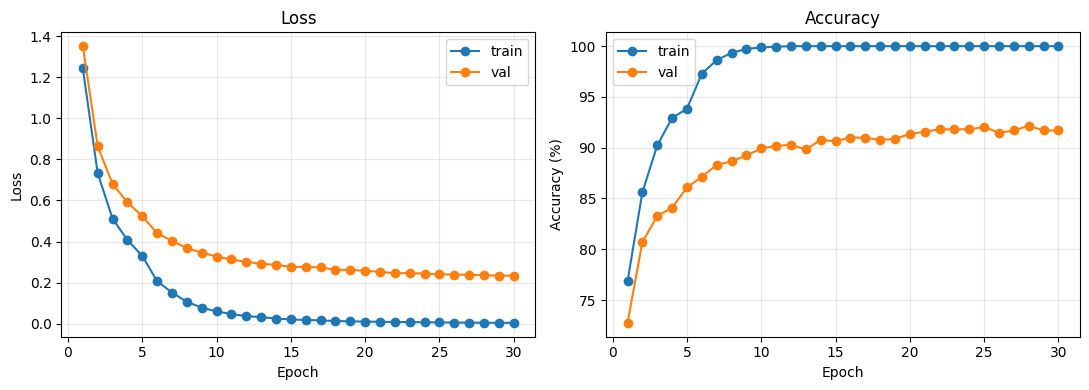

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. ImageNet 통계치 및 Transform 정의
tl_eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ★ TL-FT 전용 로더 (전역 baseline 로더를 덮어쓰지 않게 ft_ 접두사 + test도 ImageNet 정규화)
ft_train_loader      = DataLoader(TransformedSubset(train_set, tl_eval_transform), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
ft_train_eval_loader = DataLoader(TransformedSubset(train_set, tl_eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
ft_val_loader        = DataLoader(TransformedSubset(val_set,   tl_eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
ft_test_loader       = DataLoader(TransformedSubset(test_set,  tl_eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# 2. resnet18 모델 로딩
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 3. Backbone freeze
for param in model_ft.parameters():
    param.requires_grad = False

model_ft.fc = nn.Linear(model_ft.fc.in_features, 38)
model_ft = model_ft.to(device)

# 1~5 Epoch에서는 freeze 상태로 학습
optimizer_ft = torch.optim.Adam(model_ft.fc.parameters(), lr=1e-3)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

STAGE2_EPOCH = 6  # 6번째 Epoch부터 학습률 차등 + Unfreeze 적용

for ep in range(1, EPOCHS + 1):

    if ep == STAGE2_EPOCH:
        print(f"\n>>> [Epoch {ep}] Stage 2 진입: layer4 Unfreeze + 차등 학습률(Differential LR) 적용!")
        for param in model_ft.layer4.parameters():
            param.requires_grad = True
        optimizer_ft = torch.optim.Adam([
            {'params': model_ft.layer4.parameters(), 'lr': 1e-5},
            {'params': model_ft.fc.parameters(),     'lr': 1e-4}
        ])

    train_one_epoch(model_ft, ft_train_loader, optimizer_ft, criterion)
    tr_loss, tr_acc = evaluate(model_ft, ft_train_eval_loader, criterion)
    va_loss, va_acc = evaluate(model_ft, ft_val_loader, criterion)

    history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss);   history['val_acc'].append(va_acc)

    print(f'Epoch {ep:2d}/{EPOCHS} | '
          f'train loss {tr_loss:.4f} | train acc {tr_acc*100:5.2f}% | '
          f'val loss {va_loss:.4f} | val acc {va_acc*100:5.2f}%')

test_loss, test_acc = evaluate(model_ft, ft_test_loader, criterion)   # ★ ft_test_loader로 평가
print(f'Final Test Loss: {test_loss:.4f}')
print(f'Final Test Accuracy: {test_acc*100:.2f}%')

# Train / Val accuracy 그래프
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ep_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep_range, history['train_loss'], 'o-', label='train')
axes[0].plot(ep_range, history['val_loss'], 'o-', label='val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, [a*100 for a in history['train_acc']], 'o-', label='train')
axes[1].plot(ep_range, [a*100 for a in history['val_acc']], 'o-', label='val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# 실험 요약
----------------------------------
## Fine-Tuning 사용이유
- **전이 학습을 통한 소규모 데이터셋의 한계 조정**

1,400만 장 이상의 대규모 ImageNet 데이터셋인 ResNet18의 사전학습된 가중치들을 가져와 사용함으로써, 클래스당 150장(총 5,700장 내외)으로 작게 제한된 현재의 소규모 모델이 과적합에서 벗어나 강력한 일반화 성능을 가지게 된다.

- **단계적 Unfreeze 및 차등 학습률(Discriminative LR)을 통한 정확도 향상**

사전학습 가중치를 가져와 모든 레이어에 일괄적으로 높은 학습률을 적용하면, 기존 백본이 가진 범용적 시각 지식이 무너진다. 반대로 백본을 완전히 얼려두면 현재 사용하는 모델의 특징(식물 병해 반점 포착에 특화된 시각 특징) 새로 학습할 기회가 제한되어 성능이 다소 정체될 수 있다. 그러나 차등 학습률과 단계적인 Unfreeze를 활용해 사전학습 모델의 가중치를 안전하게 보존하면서도, 새로운 식물 이미지에 모델을 정교하게 맞춤 조정할 수 있다.

----------------------------------
## Baseline 대비 최종 성능 및 비교

TL-FT 기법은 기존 Baseline 대비 가장 뚜렷한 성능 향상을 보였다. Baseline은 Best Val Accuracy 86.78%, Final Val Accuracy 84.33%, Test Accuracy 81.89%를 기록한 반면, TL-FT는 Best Val Accuracy 92.16%(epoch 28), Final Val Accuracy 91.70%, Test Accuracy 91.47%를 기록하였다.

즉 TL-FT 적용 후 최고 검증 정확도는 약 5.38%p, 최종 검증 정확도는 약 7.37%p, 테스트 정확도는 약 9.58%p 향상되었다. Fine-Tuning은 초반에는 사전학습된 ResNet18의 분류기 중심으로 안정화하고, 이후 layer4를 unfreeze하여 PlantVillage 데이터의 특징에 더 잘 적응하도록 학습하였다.

따라서 TL-FT는 사전학습된 지식을 유지하면서도 현재 데이터셋에 맞게 일부 가중치를 조정해, 높은 validation accuracy와 test accuracy를 모두 달성한 기법이라고 해석할 수 있다.
----------------------------------

## 실험 요약

### **시도한 실험 (3가지 이상)**
  1. Data Augmentation
  2. Transfer Learning - Feature Extraction
  3. Residual
  4. Transfer Learning  - Fine Tuning

###  **베이스라인 대비 기법 간 결과 비교(그래프/표) 및 가장 큰 차이를 만든 것**

In [ ]:
# @title
# 각 케이스에서 val acc 추출 후 비교 그래프
# 각 케이스에서 val acc 추출 후 비교 그래프
# Baseline
val_acc_base = [
    42.92, 60.70, 65.50, 69.47, 75.79,
    76.37, 79.65, 81.99, 81.75, 78.60,
    80.47, 82.57, 83.98, 84.68, 83.27,
    83.74, 81.52, 82.11, 83.27, 82.34,
    82.57, 81.05, 81.52, 83.98, 83.39,
    82.92, 83.74, 85.96, 84.21, 81.99
]

# AUG
val_acc_aug = [
    24.80, 46.32, 62.46, 68.89, 70.64,
    73.45, 76.37, 78.48, 71.46, 75.56,
    80.47, 80.70, 83.63, 82.81, 85.15,
    83.98, 87.25, 84.21, 86.78, 84.09,
    87.13, 86.43, 85.03, 86.78, 86.43,
    88.77, 89.36, 87.37, 87.49, 89.01
]

# Feature Extraction
val_acc_fe = [
    72.28, 82.11, 82.22, 84.33, 84.56,
    86.67, 86.90, 87.49, 87.84, 88.07,
    88.42, 88.42, 89.12, 89.47, 89.12,
    89.59, 89.12, 89.94, 90.29, 89.12,
    89.47, 89.82, 89.59, 90.29, 89.94,
    89.94, 89.59, 90.53, 90.18, 90.29
]

# Residual
val_acc_res = [
    44.44, 52.98, 62.81, 73.57, 75.09,
    68.30, 70.99, 74.27, 77.54, 81.52,
    79.42, 81.64, 83.04, 83.63, 86.90,
    83.74, 87.49, 89.47, 85.03, 84.68,
    87.37, 74.50, 80.35, 87.49, 89.71,
    73.10, 90.41, 93.80, 89.01, 92.63
]

# Fine-Tuning
val_acc_ft = [
    74.85, 81.52, 85.03, 84.68, 85.73,
    87.72, 88.65, 90.06, 89.71, 89.47,
    90.06, 90.18, 90.41, 90.88, 90.99,
    91.35, 91.46, 91.11, 91.46, 91.35,
    91.93, 92.40, 91.81, 91.93, 91.81,
    92.05, 92.05, 92.40, 91.93, 92.16
]

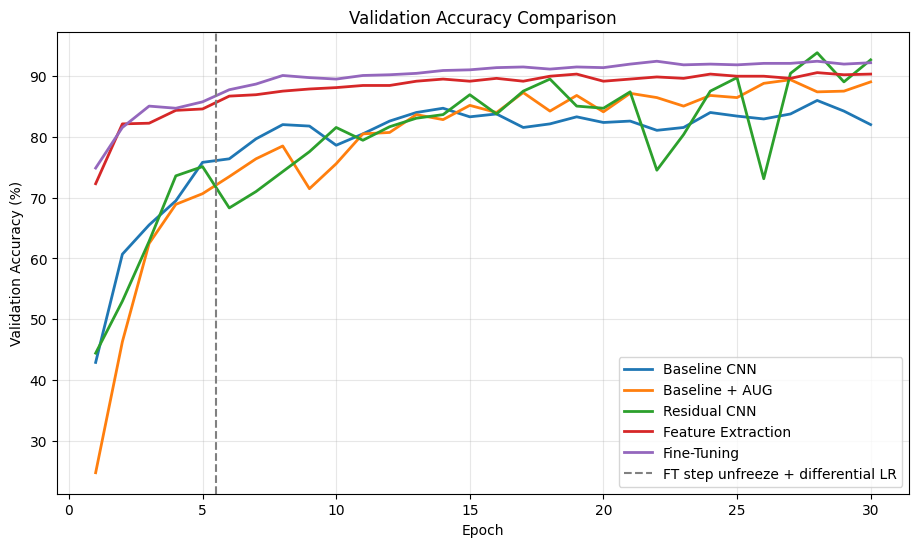

Baseline 최고 정확도     : 85.96%
Augmentation 최고 정확도 : 89.36%
Feature Extraction 최고 정확도 : 90.53%
Residual 최고 정확도    : 93.80%
Fine-Tuning 최고 정확도 : 92.40%


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 31)

plt.figure(figsize=(11,6))

plt.plot(epochs, val_acc_base, linewidth=2, label='Baseline CNN')
plt.plot(epochs, val_acc_aug, linewidth=2, label='Baseline + AUG')
plt.plot(epochs, val_acc_res, linewidth=2, label='Residual CNN')
plt.plot(epochs, val_acc_fe, linewidth=2, label='Feature Extraction')
plt.plot(epochs, val_acc_ft, linewidth=2, label='Fine-Tuning')

# Fine-Tuning stage2 시작
plt.axvline(
    x=5.5,
    linestyle='--',
    linewidth=1.5,
    color='gray',
    label='FT step unfreeze + differential LR'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'Baseline 최고 정확도     : {max(val_acc_base):.2f}%')
print(f'Augmentation 최고 정확도 : {max(val_acc_aug):.2f}%')
print(f'Feature Extraction 최고 정확도 : {max(val_acc_fe):.2f}%')
print(f'Residual 최고 정확도    : {max(val_acc_res):.2f}%')
print(f'Fine-Tuning 최고 정확도 : {max(val_acc_ft):.2f}%')

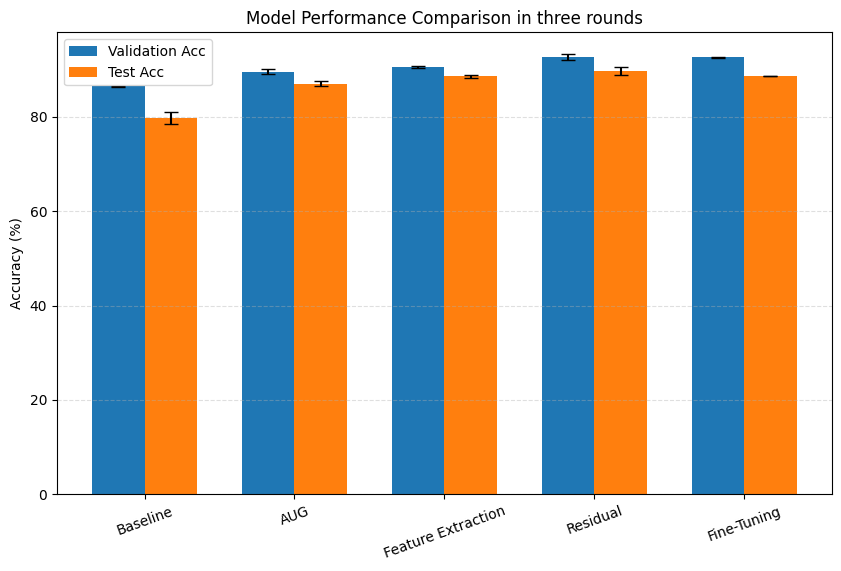

In [ ]:
# 다회차 분석 그래프
# 모든 기법을 각 3회식 테스트하여 데이터를 도출함, 각각 test acc와 최고 val acc
# 검은 막대는 표준편차를 나타내며, 이를 통해 시도마다 어느정도로 변동이 일어났는지 확인할 수 있음
methods = ["Baseline", "AUG", "Feature Extraction", "Residual", "Fine-Tuning"]

test_acc = {
    "Baseline": [78.62, 81.43, 79.21],            # 3회차 74.41 → 79.21
    "AUG": [87.62, 87.15, 86.21],
    "Feature Extraction": [88.32, 88.32, 89.02],
    "Residual": [89.14, 90.89, 89.02],
    "Fine-Tuning": [88.67, 88.55, 88.67]
}

val_acc = {
    "Baseline": [86.32, 86.32, 86.67],
    "AUG": [89.36, 90.18, 89.01],                 # 3회차 78.38(=전epoch평균이 잘못 들어감) → 89.01(최고 Val)
    "Feature Extraction": [90.53, 90.29, 90.88],
    "Residual": [91.70, 92.98, 93.10],
    "Fine-Tuning": [92.40, 92.75, 92.63]
}

methods = list(test_acc.keys())

test_mean = [np.mean(test_acc[m]) for m in methods]
test_std = [np.std(test_acc[m]) for m in methods]

val_mean = [np.mean(val_acc[m]) for m in methods]
val_std = [np.std(val_acc[m]) for m in methods]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, val_mean, width, yerr=val_std, capsize=5, label="Validation Acc")
plt.bar(x + width/2, test_mean, width, yerr=test_std, capsize=5, label="Test Acc")

plt.xticks(x, methods, rotation=20)
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison in three rounds")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

* Data Augmentation은 Baseline에 비해 안정적임
* Residual은 다른 기법에 비해 최고 성능이 약간 더 높게 나옴
* Feature Extraction은 초반 수렴 속도가 엄청 빠름
* Fine-Tuning은 초반 수렴 속도가 엄청 빠름 + Feature Extraction에 비해 정확도가 살짝 더 높음

> 아래 값은 모두 **동일 조건 3회 실행의 평균 (± 표준편차)** 이다. (4회 이상 돌린 기법은 마지막 3회 기준)

| 모델/기법 | 평균 Test Acc | 평균 최고 Val Acc | 평균 Val Acc(전 epoch) | Baseline 대비(Test) | Baseline 대비(최고 Val) |
|---|---:|---:|---:|---:|---:|
| Baseline CNN | 79.75% ± 1.21 | 86.44% ± 0.16 | 79.40% | 기준 | 기준 |
| Baseline + AUG | 86.99% ± 0.59 | 89.52% ± 0.49 | 78.66% | +7.24%p | +3.08%p |
| TL-FE | 88.55% ± 0.33 | 90.57% ± 0.24 | 88.48% | +8.80%p | +4.13%p |
| Residual CNN | 89.68% ± 0.85 | 92.59% ± 0.63 | 80.54% | +9.93%p | +6.16%p |
| TL-FT | 88.63% ± 0.06 | 92.59% ± 0.15 | 89.41% | +8.88%p | +6.16%p |

종합 그래프의 단일 최고 Val Accuracy 기준으로는 Residual CNN이 93.80%로 가장 높았고, Fine-Tuning 92.40%, Feature Extraction 90.53%, AUG 89.36%, Baseline 85.96% 순으로 나타났다.

다만 3회 평균 기준으로 보면 Residual과 Fine-Tuning의 평균 최고 Val Accuracy는 모두 92.59%로 사실상 동률이었다. Test Accuracy 평균은 Residual이 89.68%로 가장 높았지만, 표준편차도 상대적으로 커 실행마다 변동이 있었다. 반면 Fine-Tuning은 평균 최고 Val Accuracy가 Residual과 비슷하면서 표준편차가 작아 더 안정적인 기법으로 볼 수 있다.

정리하면 Residual은 성능 상한과 평균 Test Accuracy가 가장 높은 기법이고, Fine-Tuning은 높은 검증 성능을 가장 안정적으로 내는 기법이다.





### 그 결과가 왜 그렇게 나왔는지에 대한 우리 팀의 해석
Data Augmentation은 변형을 가한 입력을 함께 학습시키기 때문에, 모델이 특정 패턴을 외우기보다 다양한 형태에 견디도록 학습된다. 데이터를 새로 모으지 않고도 학습 데이터의 다양성을 키워 과적합을 줄이는 방식이라, 데이터셋이 작거나 추가 수집이 어려운 상황에 잘 맞는다.
Residual은 Augmentation처럼 데이터나 학습 방식만 손대는 게 아니라, Skip Connection을 넣어 네트워크 구조 자체를 바꾼 경우다. 사전학습 가중치 없이 처음부터 학습하다 보니 초반에는 TL 기법들보다 안정화가 느리고 정확도도 낮게 출발하지만, 학습이 충분히 쌓이면 시도한 기법 중 가장 높은 정확도에 도달한다. 층이 깊어 복잡한 패턴을 학습해야 하거나, 시간이 좀 더 들더라도 최종 성능을 끝까지 끌어올리고 싶을 때 유리하다.
Feature Extraction은 사전학습된 모델을 가져와 backbone은 freeze한 채 classifier(fc layer)만 학습한다. 이미 잘 학습된 가중치를 그대로 쓰는 셈이라 학습이 빠르게 안정화되고, 적은 epoch에서도 높은 정확도가 나온다. 데이터셋이 작거나 GPU 자원이 빠듯할 때, 학습 시간을 줄이면서 빠르게 쓸 만한 성능을 얻고 싶을 때 적합하다.
Fine-Tuning도 사전학습 모델을 쓴다는 점에서 Feature Extraction과 출발은 비슷해서, 빠른 안정화와 적은 epoch 대비 높은 정확도라는 장점을 공유한다. 다만 처음엔 freeze 상태로 학습하다가 이후 일부 layer를 unfreeze하기 때문에, backbone이 PlantVillage 데이터 고유의 특징까지 추가로 학습한다. 그만큼 Feature Extraction보다 조금 더 높은 정확도를 기대할 수 있다.

## 최종 성능 평가

시도한 기법들을 종합하면, 기본적으로는 Fine-Tuning이 가장 무난했고, 조건이 맞을 때 한정으로는 Residual이 더 나았다고 본다.
Fine-Tuning은 이미 잘 학습된 모델에서 출발하니 안정화가 빠르고 작은 데이터셋에서도 무리 없이 동작한다. 그래서 학습 초반부터 다른 두 기법이나 Baseline보다 빠르게 자리를 잡고, Baseline보다 성능도 분명히 높다. 게다가 전체를 freeze해두는 게 아니라 필요한 만큼 단계적으로 layer를 풀어주기 때문에 데이터 고유의 특징까지 잡아내, Feature Extraction보다도 정확도가 소폭 앞선다.
그런데 epoch가 쌓여 후반으로 갈수록 순위가 뒤집혀 Residual이 더 높은 정확도를 보인다. Fine-Tuning은 결국 일부 layer만 풀고 backbone 대부분은 고정한 상태라 데이터에 맞춰 적응할 여지가 제한적인 반면, Residual은 Skip Connection 덕분에 기울기 소실과 degradation 문제에서 비교적 자유롭고 네트워크 전체가 PlantVillage에 맞게 학습된다. 구조적으로 더 깊이 적응할 수 있으니 최종 도달하는 정확도도 더 높게 나온 것으로 보인다.
다만 Residual은 일부 구간에서 Loss와 Accuracy가 눈에 띄게 출렁인다. 해당 구간에서 학습률이 높아 오버슈팅이 생긴 탓이다. 이번 실험은 기법 간 비교를 공정하게 맞추는 게 목적이라, 특정 기법에만 유리해질 수 있는 학습률 스케줄링은 일부러 넣지 않았고 그래서 이 변동을 그대로 두었다. 실제로 Residual을 쓸 거라면 scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)처럼 스케줄러를 두고 매 epoch 종료 시 scheduler.step()을 호출해 학습률을 점차 낮춰주면 이런 오버슈팅을 줄일 수 있다.


### 예상과 달랐던 점 / 더 해보고 싶었던 것

처음에는 Fine-Tuning이 가장 높은 성능을 낼 것이라고 예상했다. ImageNet으로 사전학습된 ResNet18을 사용하고, 초반에는 backbone을 freeze한 뒤 이후 일부 layer를 unfreeze하는 방식이기 때문에 작은 데이터셋에서는 가장 안정적이고 높은 성능을 낼 것이라고 생각했기 때문이다.

하지만 단일 최고 Validation Accuracy 기준으로는 Residual CNN이 93.80%로 가장 높게 나타났다. Fine-Tuning의 단일 최고 Validation Accuracy는 92.40%였기 때문에, 최고점만 놓고 보면 Residual이 더 좋은 결과를 보였다. 이 부분은 예상과 달랐다. 사전학습 가중치 없이 처음부터 학습한 모델이 Transfer Learning 기반 모델보다 더 높은 최고 성능을 낸 것이기 때문이다.

다만 3회 평균 결과까지 함께 보면 해석이 조금 달라진다. Residual CNN과 Fine-Tuning의 평균 최고 Val Accuracy는 둘 다 92.59%로 같았다. 또한 평균 Test Accuracy는 Residual CNN이 89.68%로 가장 높았지만, 표준편차가 ±0.85로 Fine-Tuning의 ±0.06보다 컸다. 즉 Residual은 최고 성능과 Test 성능의 상한은 높았지만, 실행마다 결과가 조금 더 흔들리는 편이었다. 반대로 Fine-Tuning은 최고점이 Residual보다 약간 낮게 나온 경우가 있었지만, 결과가 훨씬 안정적으로 반복되었다.

이 점에서 우리 팀은 Residual CNN을 “성능을 끝까지 끌어올릴 가능성이 큰 방법”, Fine-Tuning을 “실제로 사용하기에 안정적인 방법”으로 해석했다. Residual은 Skip Connection 덕분에 깊어진 구조에서도 특징을 잘 학습할 수 있었고, PlantVillage 데이터에 맞게 전체 네트워크가 자유롭게 조정되면서 높은 최고 성능을 낸 것으로 보인다. 하지만 학습 중간에 Accuracy와 Loss가 크게 흔들리는 구간이 있었기 때문에, 학습률이나 epoch 조건에 민감한 모델이라고 느꼈다.

Baseline도 예상보다 성능이 높았다. 평균 Test Accuracy는 79.75%였고, 평균 최고 Val Accuracy도 86.44%까지 나왔다. 처음에는 기본 CNN이라 성능 차이가 더 크게 날 것이라고 생각했지만, PlantVillage 데이터셋은 잎 이미지가 비교적 정제되어 있고 병해의 시각적 특징이 뚜렷해서 Baseline만으로도 어느 정도 분류가 가능했던 것으로 보인다. 다만 Baseline은 train 성능에 비해 validation/test 성능이 낮아지는 경향이 있어, 높은 학습 정확도가 곧 좋은 일반화 성능을 의미하지는 않는다는 점도 확인할 수 있었다.

더 해보고 싶은 점은 Residual CNN에 learning rate scheduler나 early stopping을 적용해 보는 것이다. 현재 실험에서는 기법 간 비교 조건을 맞추기 위해 scheduler를 넣지 않았지만, Residual의 성능 변동이 학습률 영향으로 보였기 때문에 scheduler를 적용하면 더 안정적으로 높은 성능에 도달할 수 있을 것 같다. 또한 Fine-Tuning에서는 unfreeze 범위를 `layer4`에만 둘 것이 아니라 `layer3`까지 넓히거나, 차등 학습률을 다르게 설정해 보면 Residual과 비슷한 최고 성능을 유지하면서도 더 안정적인 결과를 얻을 수 있을지 확인해 보고 싶다.





### 다른 팀에게 추천

- 빠르게 안정적인 성능을 얻고 싶다면 Fine-Tuning을 추천한다. 사전학습된 모델을 가져온다는 특성상 작은 데이터셋에서도 높은 검증 정확도를 안정적으로 얻을 수 있고, unfreeze 범위와 학습률을 조절하며 데이터셋에 맞게 모델을 변경하기도 쉽다.

- 최고 성능과 높은 Test Accuracy를 목표로 한다면 Residual 구조를 추천한다. 다른 기법에 비해 skip connection이라는 특유의 구조가 추가되어 CNN에 익숙하지 않은 사람이 구조를 파악하는 것에 도움을 준다. 또한 층이 깊어져도 과적합의 위험을 가지는 다른 모델에 비해 깊은 네트워크에서도 초기에 학습한 특징을 그대로 가지고 있어 높은 표현력을 체감할 수 있다. 다만 단독으로 사용할 경우 epoch 중간에 성능 변동이 생길 수 있기 때문에 learning rate scheduler나 early stopping을 함께 쓰는 것이 좋다.

- 구현 난이도를 낮게 유지하면서 과적합을 줄이고 싶다면 Data Augmentation을 추천한다. Baseline 대비 validation/test 성능이 모두 개선되었고, 데이터의 추가나 모델 구조의 변경없이도 적용할 수 있다는 장점이 있다.

- Residual 파라미터 수가 너무 커 성능이 낮게 나온 경우, AdaptiveAvgPool2d(1)을 사용하여 GAP를 적용시키는 것이 좋다. 간단히 요약하면 Feature Map의 전체 평균을 구해 하나로 압축하는 방식인데, 이를 통해 특징의 위치보다 특징의 존재에 집중하게 만든다. 현재 데이터셋 같이 병변의 위치보다 존재가 중요한 문제에서 일반화 성능 향상에 도움을 줄 수 있다.

## 변경 요약

### 1. 실험 3 (Residual), 실험 4 (TL-FT)의 test acc 추가

- 변경 이유: Residual, TL-FT 두 기법의 성능평가에서 test acc를 누락했으며, 이로인해 val acc 및 train acc 간의 차이와 최고 val acc를 기준으로 평가하여 모델의 성능 평가에 부적절한 부분이 있었다.
- 결과 : 모든 기법에 test acc가 추가됨으로써 최고 val acc와 test acc를 함께 고려하여 보다 합리적인 성능 비교가 가능해졌으며 모델의 일반화 성능이라는 중요한 성능 지표를 중심으로 비교할 수 있게 되었다.



### 2. 실험 3 (Residual)의 성능 향상의 서술 정정

- 변경 이유: Residual의 높은 성능은 Skip Connection과 전체 네트워크가 데이터에 맞게 학습된다는 두 가지 특징을 가지고 있음에도 후자의 특징을 성능의 핵심 원인으로 서술했었다.
- 결과 : Residual의 두 이점을 같이 서술하여 높은 성능에 기여한 주요 특징인 Skip Connection과 학습과정에서의 장점과 함께 서술하여 결론을 보완했다.


### 3. 3회차에 걸친 결과 분석

- 변경 이유: 기존에는 코드의 실행마다 다소 결과가 달라지는 부분이 존재해 코드를 실행하는 사용자에 따라 결과가 달라질 수 있었다.
- 결과 : 실행마다 결과가 조금씩 달라지는 것을 고려하여 각 실험을 3번 이상 반복 실행한 뒤 실험을 분석하면서 test acc와 최고 val acc, train acc와의 차이를 기준으로 종합적인 판단(안정성 포함)을 내렸다. 이를 통해 단일 실행 결과에 의존하지 않고 보다 신뢰성 있는 평가를 수행할 수 있었다.

### 4. 안정성 관련 서술 추가

- 변경 이유: Residual은 일부 구간에서 오버 슈팅이 일어나 정확도 크게 하락하는 구간이 있었고, 큰 변동폭에 비해 최고 성능을 가른 구간이 작아 Residual이 가장 좋은 기법이 맞는지에 대한 질문을 받음
- 결과 : 이에 대한 원인을 분석한 결과 해당 구간에서 학습률이 너무 커 수렴하지 못하고 튕겨나온다는 것을 알게 되었다. 그래서 이를 해결법으로 학습률 스케쥴링을 도입하는 방법을 찾아냈음. 또한 안정성도 성능의 주요 평가 기준으로 삼아 이를 평가에 반영함
